In [167]:
import pandas as pd 
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_model import ARIMA

#relax the display limits on columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import warnings
warnings.filterwarnings('ignore')


In [169]:
import pandas as pd
import os

folder_path = r"C:\Users\fergu\OneDrive\Documents\Masters in Data Analytics\CA\msc-da-integrated-ca2-sem2-sba24330\stockprice"

file_names = {
    "AAPL": "AAPL.csv",
    "AMZN": "AMZN.csv",
    "BA": "BA.csv",
    "DIS": "DIS.csv",
    "TSLA": "TSLA.csv"
}

# Read and label each file
merged_data = []

for ticker, file_name in file_names.items():
    file_path = os.path.join(folder_path, file_name)
    df = pd.read_csv(file_path)
    df['ticker'] = ticker
    merged_data.append(df)

# Combine all into one DataFrame
stock_price = pd.concat(merged_data, ignore_index=True)


print(stock_price.head())

         Date       Open       High        Low      Close  Adj Close  \
0  2019-12-31  72.482498  73.419998  72.379997  73.412498  71.520821   
1  2020-01-02  74.059998  75.150002  73.797501  75.087502  73.152649   
2  2020-01-03  74.287498  75.144997  74.125000  74.357498  72.441460   
3  2020-01-06  73.447502  74.989998  73.187500  74.949997  73.018677   
4  2020-01-07  74.959999  75.224998  74.370003  74.597504  72.675278   

      Volume ticker  
0  100805600   AAPL  
1  135480400   AAPL  
2  146322800   AAPL  
3  118387200   AAPL  
4  108872000   AAPL  


In [5]:
# when merging the stock price with the tweets file (post sentiment analysis) we will take the compund score instead of the 
#one hot encoded values as we only need one numberical value for the sentiment in autoregression

In [9]:
# so the above shows use that all companies except for ABNB have 254 rows of data relating to stock price, which alignes with the total number of days the stock market is open
# therefore we have a complete data set for time series analysis. So we next we will look at whic companies has the most days where there is at least
# one tweet (not the total count). We most the most days where there is a tweet so we can perform time series analsis.... talk more about this in the
# word doc

In [13]:
# so for our analysis we will look at 'TSLA', 'AAPL', 'BA', 'DIS', 'AMZN' as they have the most complete dataset

In [173]:
import pandas as pd

# Load sentiment dataset csv file as the calcualtions were done in the other coding file (stock prioces dataset already loaded above)
sentiment_df = pd.read_csv("stocktweet_sentiment.csv")

# Standardize column names
sentiment_df.rename(columns={'date': 'Date', 'Ticker': 'ticker'}, inplace=True)
stock_price.rename(columns={'Ticker': 'ticker', 'Adj Close': 'adj_close'}, inplace=True)

# Convert 'Date' columns to datetime
sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date'], dayfirst=True)
stock_price['Date'] = pd.to_datetime(stock_price['Date'])

# Merge on 'Date' and 'ticker'
merged_df = pd.merge(
    stock_price[['Date', 'ticker', 'adj_close']],
    sentiment_df[['Date', 'ticker', 'compound']],
    on=['Date', 'ticker'],
    how='left'
)

# Forward-fill missing compound sentiment values by ticker
merged_df['compound'] = merged_df.groupby('ticker')['compound'].fillna(method='ffill')

# Display preview
print(merged_df.head(20))


         Date ticker  adj_close  compound
0  2019-12-31   AAPL  71.520821       NaN
1  2020-01-02   AAPL  73.152649  0.403325
2  2020-01-03   AAPL  72.441460  0.138200
3  2020-01-06   AAPL  73.018677  0.725150
4  2020-01-07   AAPL  72.675278 -0.028933
5  2020-01-08   AAPL  73.844353  0.011267
6  2020-01-09   AAPL  75.412880  0.413450
7  2020-01-10   AAPL  75.583344  0.401750
8  2020-01-13   AAPL  77.198143  0.316250
9  2020-01-14   AAPL  76.155716  0.423100
10 2020-01-15   AAPL  75.829361  0.376600
11 2020-01-16   AAPL  76.779221  0.276150
12 2020-01-17   AAPL  77.629234  0.215867
13 2020-01-21   AAPL  77.103165  0.670500
14 2020-01-22   AAPL  77.378380  0.670500
15 2020-01-23   AAPL  77.751030  0.212300
16 2020-01-24   AAPL  77.526955  0.000000
17 2020-01-27   AAPL  75.247253 -0.013620
18 2020-01-28   AAPL  77.375946  0.257977
19 2020-01-29   AAPL  78.995605  0.343443


In [253]:
# Since multiple tweets may exist per day per company, daily averages of compound scores have been calculated.

In [71]:
tsla_ar = merged_df[merged_df['ticker'] == 'TSLA']

In [49]:
# starting point is here when you want to rerun the code for the other tikcers

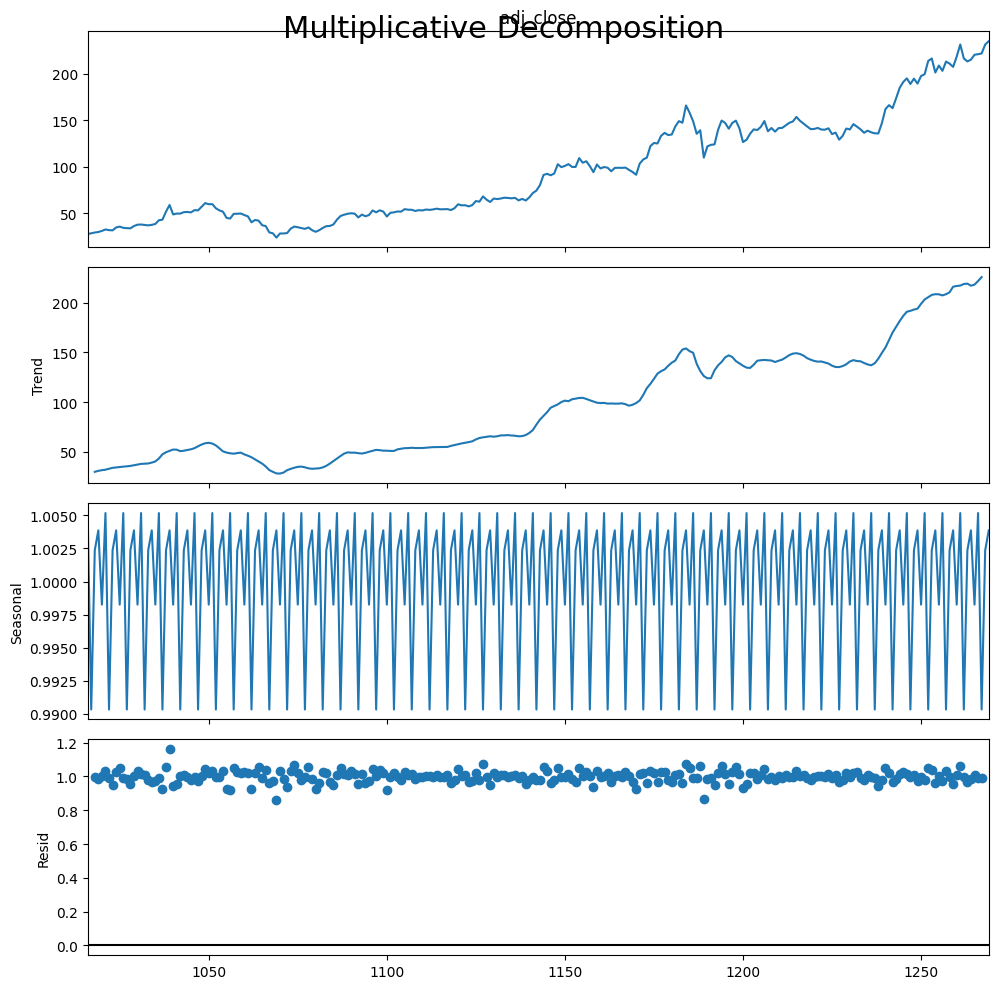

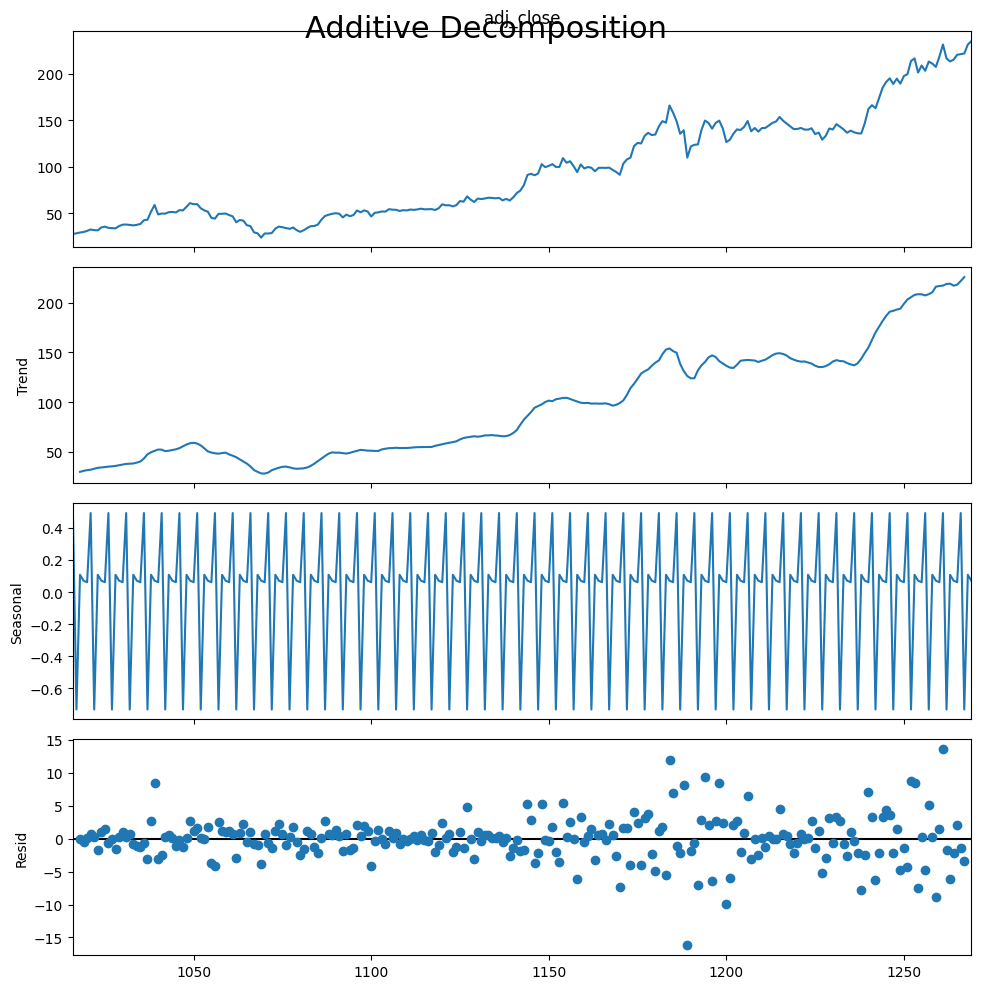

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition (5 = weekly pattern for daily stock data)
result_mul = seasonal_decompose(tsla_ar['adj_close'], model='multiplicative', period=5)
result_add = seasonal_decompose(tsla_ar['adj_close'], model='additive', period=5)

# Plot the results
plt.rcParams.update({'figure.figsize': (10, 10)})
result_mul.plot().suptitle('Multiplicative Decomposition', fontsize=22)
result_add.plot().suptitle('Additive Decomposition', fontsize=22)
plt.show()

In [35]:
# There is seasonaility so I will use SARIMAX model. I'm using SARIMAZ not SARIMA as the dataset contains Exogenous data

In [75]:
from statsmodels.tsa.stattools import adfuller

# Ensure data is sorted by date
tsla_ar = tsla_ar.sort_values("Date")

# Select the series to test (e.g. adjusted closing price)
series = tsla_ar['adj_close']

# Apply ADF test
result = adfuller(series)

# Print results
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Used lags:", result[2])
print("Observations:", result[3])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: 0.7974363347361546
p-value: 0.9915946727631736
Used lags: 0
Observations: 253
Critical Values:
   1%: -3.4564641849494113
   5%: -2.873032730098417
   10%: -2.572894516864816


In [41]:
# dataset is not stationary. need to difference the dataset

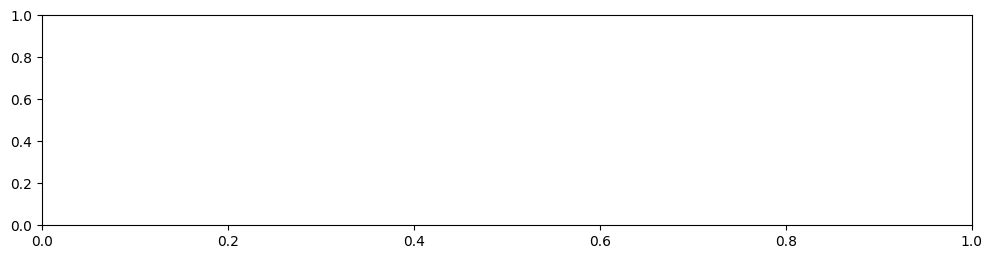

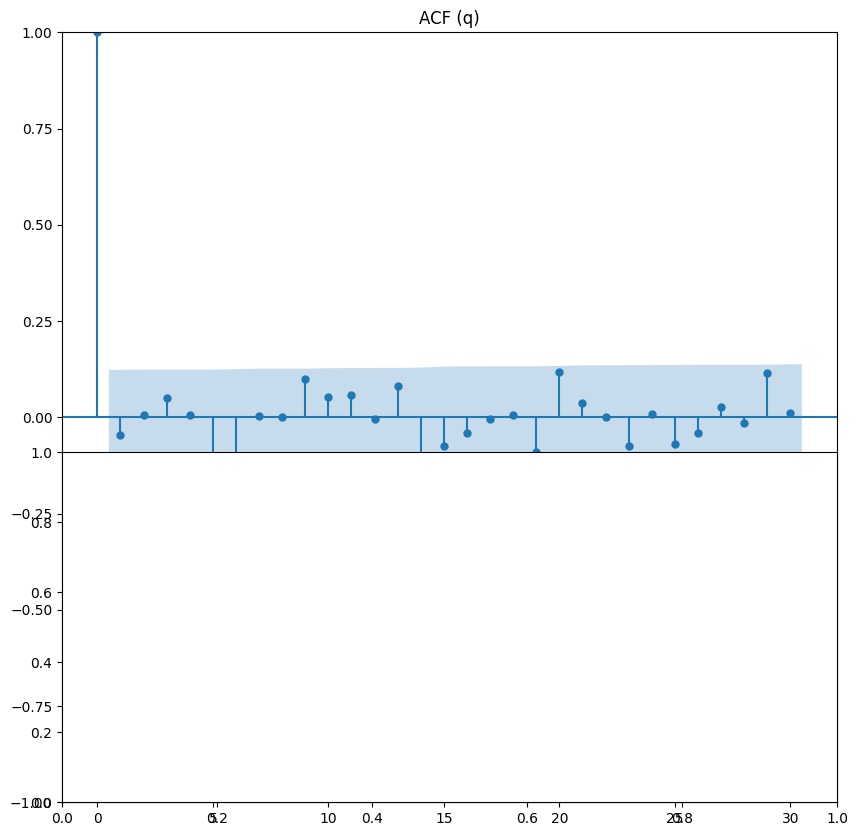

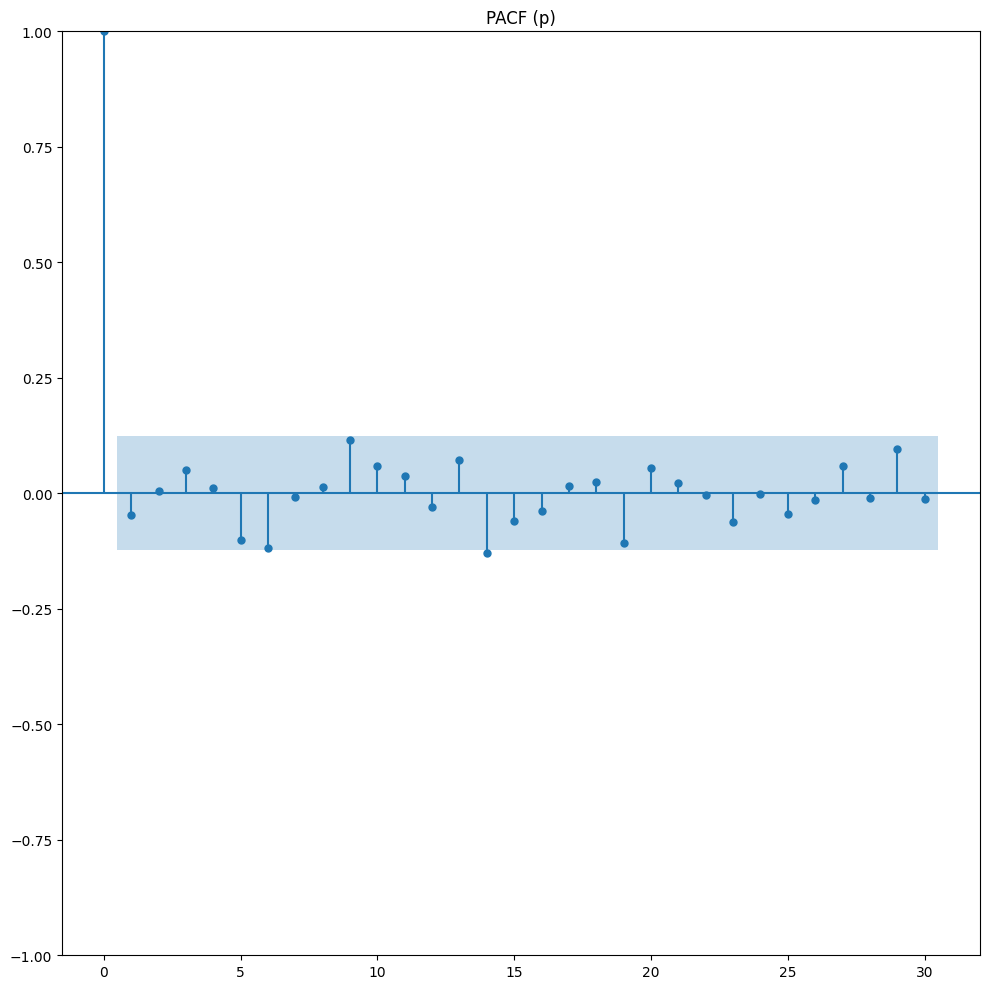

In [77]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt


# Difference the 'adj_close' column to make it stationary
tsla_ar['adj_close_diff'] = tsla_ar['adj_close'].diff()
diff_series = tsla_ar['adj_close_diff'].dropna()

# Plot ACF and PACF
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plot_acf(diff_series, lags=30)
plt.title('ACF (q)')

plt.subplot(2, 1, 2)
plot_pacf(diff_series, lags=30)
plt.title('PACF (p)')

plt.tight_layout()
plt.show()


In [117]:
# discuss above. Dataset is now stationary and suitbale for modelling

Actual vs Predicted (First 7 Days of December 2020):
      Date  Actual adj_close  Predicted adj_close
2020-12-01        194.919998           189.593596
2020-12-02        189.606674           189.130612
2020-12-03        197.793335           188.305381
2020-12-04        199.679993           189.236882
2020-12-07        213.919998           189.731106
2020-12-08        216.626663           191.490448
2020-12-09        201.493332           193.182680


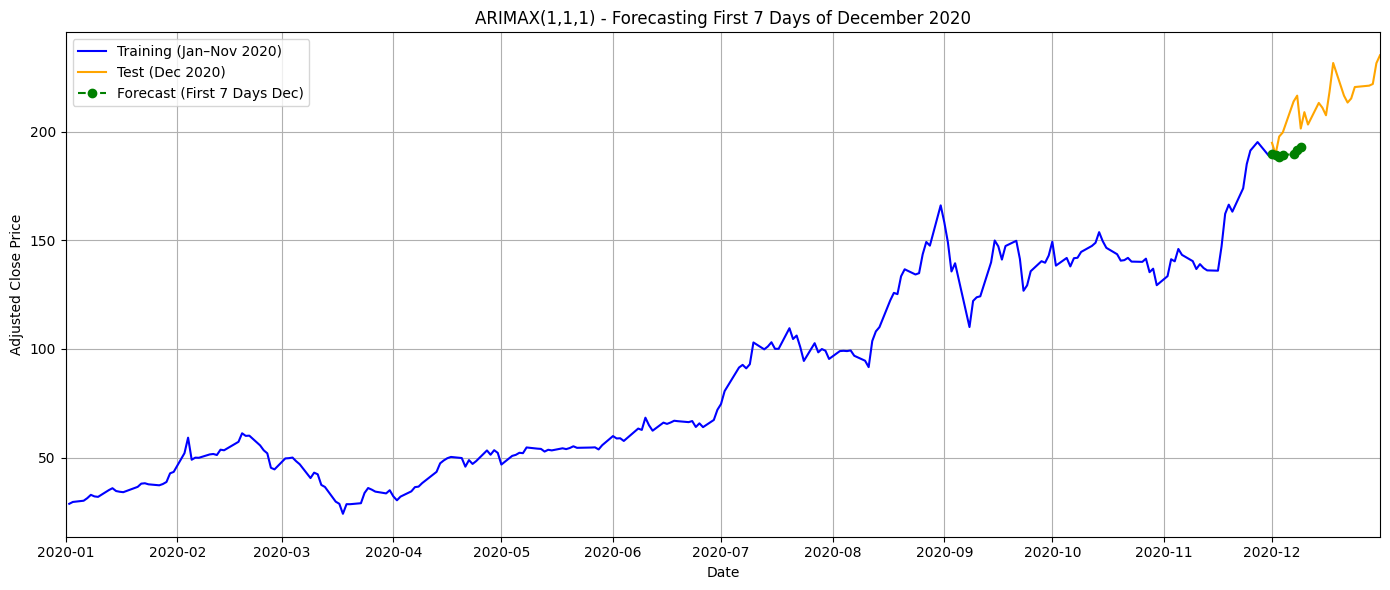

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Extract month and year
tsla_ar['month'] = tsla_ar['Date'].dt.month
tsla_ar['year'] = tsla_ar['Date'].dt.year

# Filter data for 2020 only
tsla_ar = tsla_ar[tsla_ar['year'] == 2020].copy()

# Train: Jan to Nov 2020
train_df = tsla_ar[tsla_ar['month'] < 12]

# Test: Dec 2020
test_df = tsla_ar[tsla_ar['month'] == 12]

# SARIMAX model
endog = train_df['adj_close']
exog = train_df[['compound']]
model = SARIMAX(endog, exog=exog, order=(1, 1, 1), seasonal_order=(1, 1, 1, 5))
results = model.fit(disp=False)

# Forecast first 7 days of Dec 2020
forecast_exog = test_df[['compound']].iloc[:7]
forecast = results.get_forecast(steps=7, exog=forecast_exog)
forecast_values = forecast.predicted_mean
forecast_dates = test_df['Date'].iloc[:7]

# Compare actual vs predicted for the first 7 days
comparison_df = pd.DataFrame({
    'Date': forecast_dates.values,
    'Actual adj_close': test_df['adj_close'].iloc[:7].values,
    'Predicted adj_close': forecast_values.values
})

print("Actual vs Predicted (First 7 Days of December 2020):")
print(comparison_df.to_string(index=False))

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(train_df['Date'], train_df['adj_close'], label='Training (Jan–Nov 2020)', color='blue')
plt.plot(test_df['Date'], test_df['adj_close'], label='Test (Dec 2020)', color='orange')
plt.plot(forecast_dates, forecast_values, label='Forecast (First 7 Days Dec)', color='green', marker='o', linestyle='--')

plt.title("ARIMAX(1,1,1) - Forecasting First 7 Days of December 2020")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"))
plt.show()

Actual vs Predicted (Days 1, 3, and 7 of December 2020):
      Date  Actual adj_close  Predicted adj_close
2020-12-01        194.919998           189.593596
2020-12-03        197.793335           188.305381
2020-12-09        201.493332           193.182680


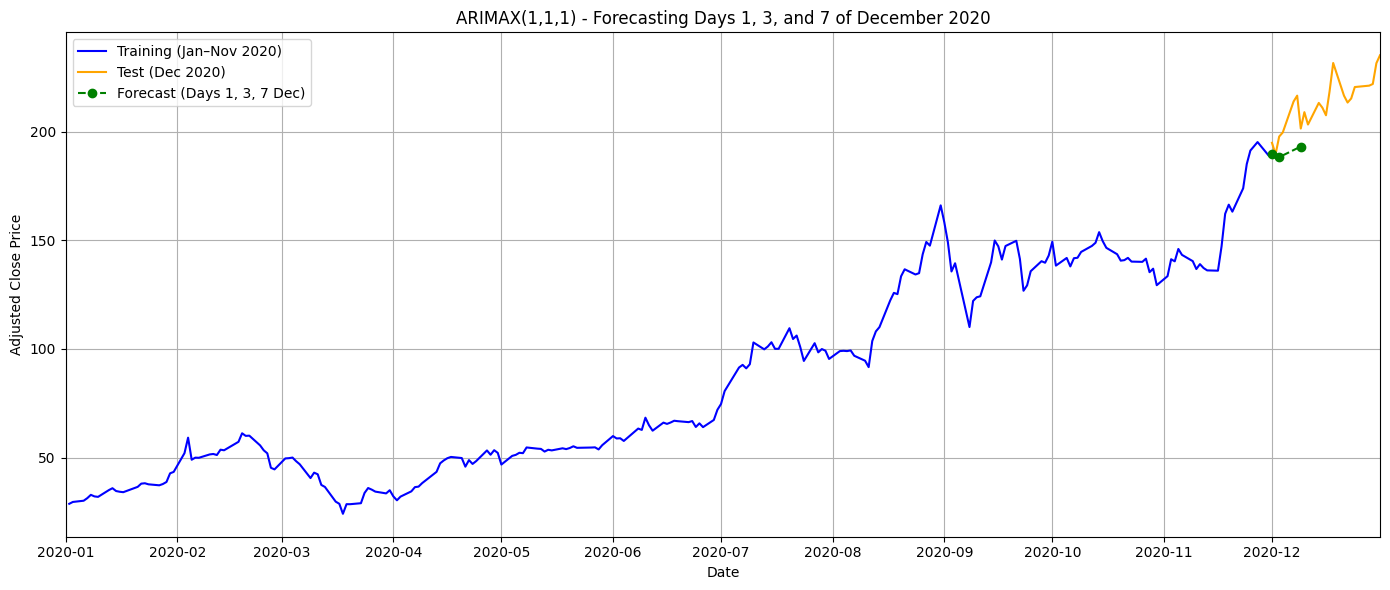

In [55]:
# Select only Days 1, 3, and 7: indices 0, 2, 6
selected_indices = [0, 2, 6]
forecast_subset = forecast_values.iloc[selected_indices]
dates_subset = forecast_dates.iloc[selected_indices]
actual_subset = test_df['adj_close'].iloc[selected_indices].values

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Date': dates_subset.values,
    'Actual adj_close': actual_subset,
    'Predicted adj_close': forecast_subset.values
})

print("Actual vs Predicted (Days 1, 3, and 7 of December 2020):")
print(comparison_df.to_string(index=False))

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(train_df['Date'], train_df['adj_close'], label='Training (Jan–Nov 2020)', color='blue')
plt.plot(test_df['Date'], test_df['adj_close'], label='Test (Dec 2020)', color='orange')
plt.plot(dates_subset, forecast_subset, label='Forecast (Days 1, 3, 7 Dec)', color='green', marker='o', linestyle='--')

plt.title("ARIMAX(1,1,1) - Forecasting Days 1, 3, and 7 of December 2020")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"))
plt.show()


In [59]:
# can you save the results to a csv file? so I can export it to the dashboard

In [61]:
#optimise the parameters

Actual vs Predicted (Days 1, 3, and 7 of December 2020):
      Date  Actual adj_close  Predicted adj_close
2020-12-01        194.919998           189.593596
2020-12-03        197.793335           188.305381
2020-12-09        201.493332           193.182680


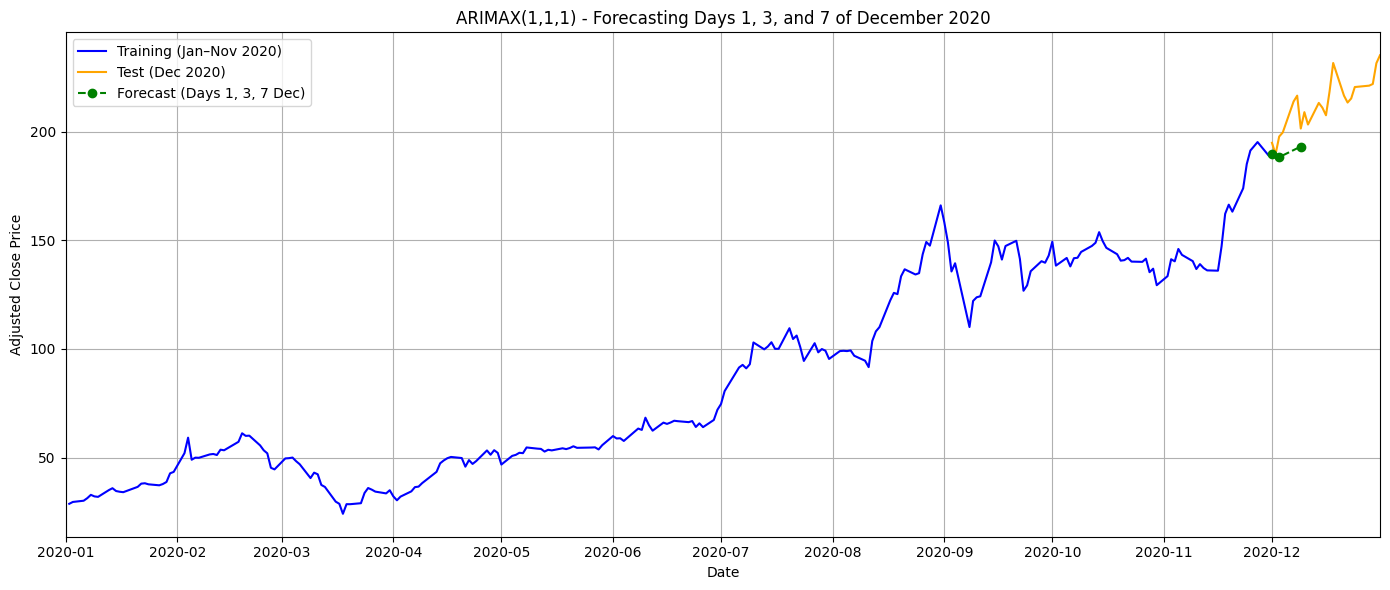

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Extract month and year
tsla_ar['month'] = tsla_ar['Date'].dt.month
tsla_ar['year'] = tsla_ar['Date'].dt.year

# Filter data for 2020 only
tsla_ar = tsla_ar[tsla_ar['year'] == 2020].copy()

# Train: Jan to Nov 2020
train_df = tsla_ar[tsla_ar['month'] < 12]

# Test: Dec 2020
test_df = tsla_ar[tsla_ar['month'] == 12]

# SARIMAX model
endog = train_df['adj_close']
exog = train_df[['compound']]
model = SARIMAX(endog, exog=exog, order=(1, 1, 1), seasonal_order=(1, 1, 1, 5))
results = model.fit(disp=False)

# Forecast first 7 days of Dec 2020
forecast_exog = test_df[['compound']].iloc[:7]
forecast = results.get_forecast(steps=7, exog=forecast_exog)
forecast_values = forecast.predicted_mean
forecast_dates = test_df['Date'].iloc[:7]
actual_values = test_df['adj_close'].iloc[:7]

# Select Days 1, 3, and 7 (indices 0, 2, 6)
selected_indices = [0, 2, 6]
dates_subset = forecast_dates.iloc[selected_indices]
forecast_subset = forecast_values.iloc[selected_indices]
actual_subset = actual_values.iloc[selected_indices]

# Compare actual vs predicted
comparison_df = pd.DataFrame({
    'Date': dates_subset.values,
    'Actual adj_close': actual_subset.values,
    'Predicted adj_close': forecast_subset.values
})

print("Actual vs Predicted (Days 1, 3, and 7 of December 2020):")
print(comparison_df.to_string(index=False))

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(train_df['Date'], train_df['adj_close'], label='Training (Jan–Nov 2020)', color='blue')
plt.plot(test_df['Date'], test_df['adj_close'], label='Test (Dec 2020)', color='orange')
plt.plot(dates_subset, forecast_subset, label='Forecast (Days 1, 3, 7 Dec)', color='green', marker='o', linestyle='--')

plt.title("ARIMAX(1,1,1) - Forecasting Days 1, 3, and 7 of December 2020")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"))
plt.show()


In [107]:
aapl_ar = merged_df[merged_df['ticker'] == 'AAPL']

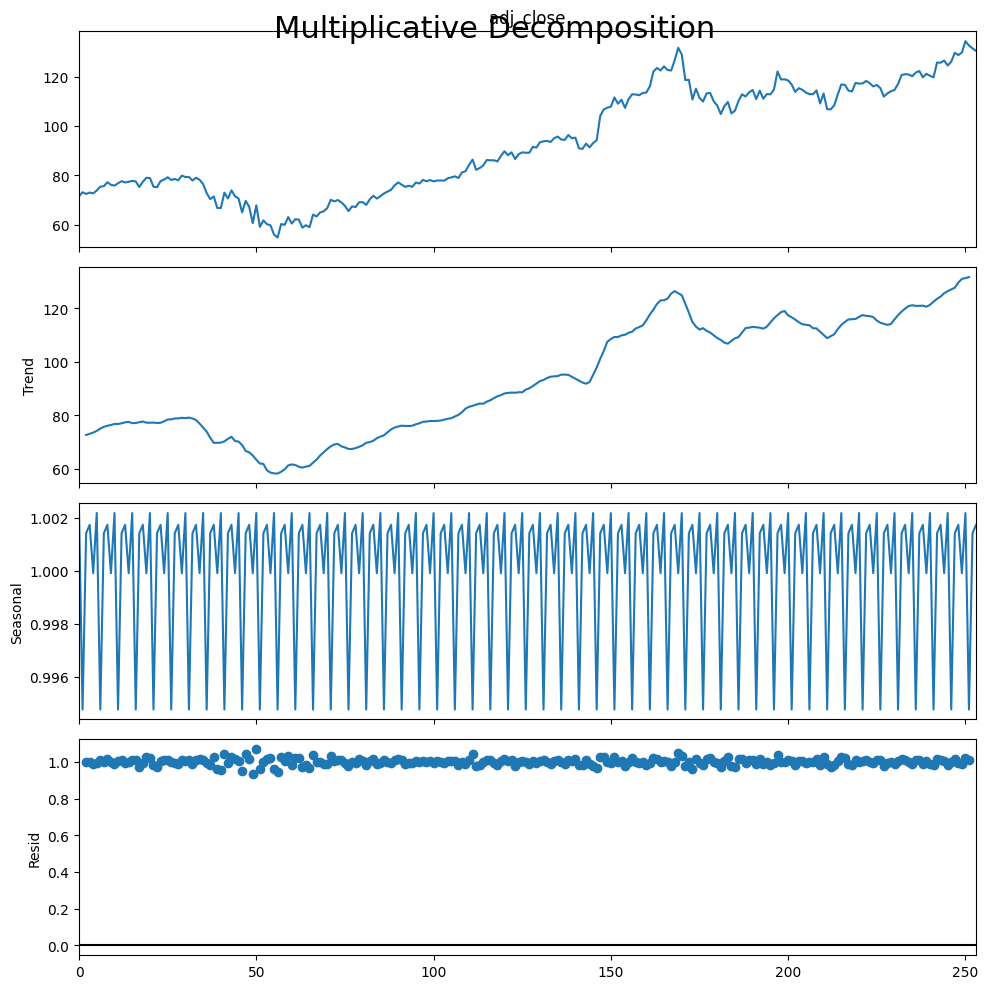

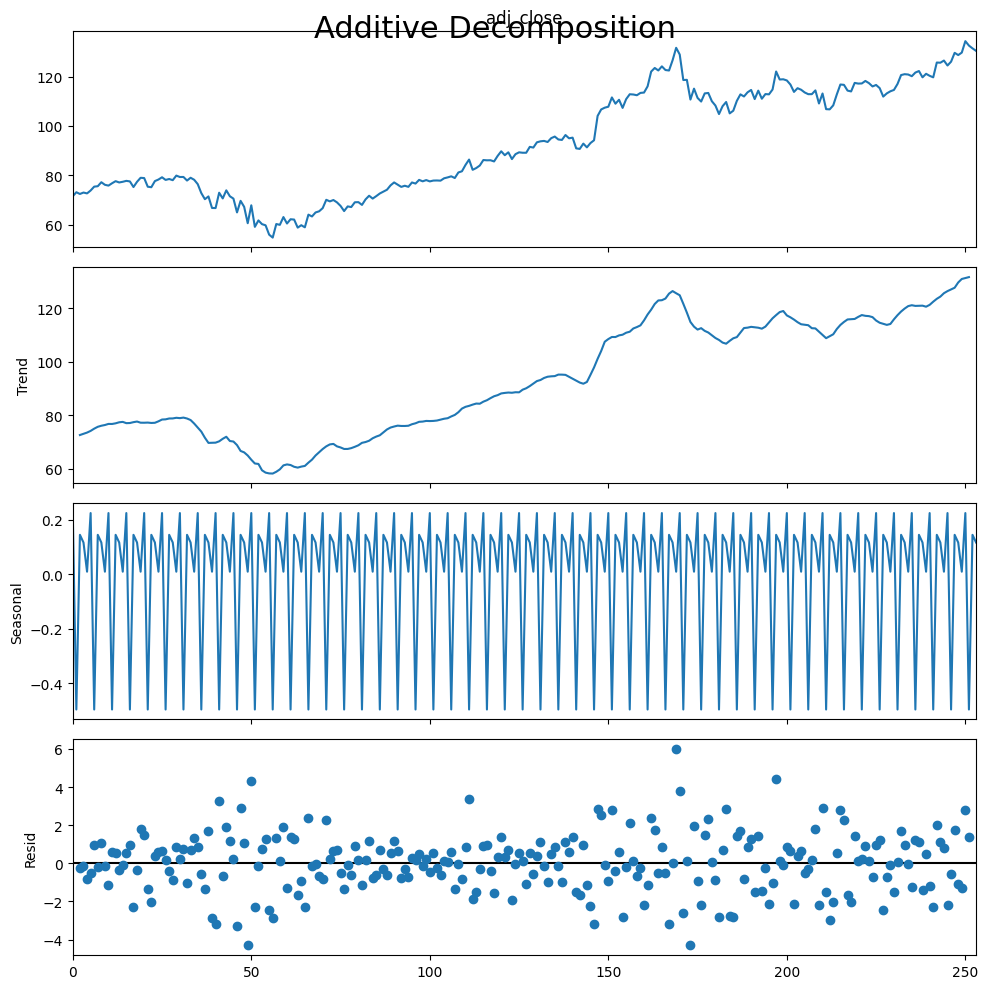

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition (5 = weekly pattern for daily stock data)
result_mul = seasonal_decompose(aapl_ar['adj_close'], model='multiplicative', period=5)
result_add = seasonal_decompose(aapl_ar['adj_close'], model='additive', period=5)

# Plot the results
plt.rcParams.update({'figure.figsize': (10, 10)})
result_mul.plot().suptitle('Multiplicative Decomposition', fontsize=22)
result_add.plot().suptitle('Additive Decomposition', fontsize=22)
plt.show()

In [137]:
# the above graphs show that there is a trend (confirm non stationary below) and there is seasonility of 5 days

In [111]:
from statsmodels.tsa.stattools import adfuller

# Ensure data is sorted by date
aapl_ar = aapl_ar.sort_values("Date")

# Select the series to test (e.g. adjusted closing price)
series = aapl_ar['adj_close']

# Apply ADF test
result = adfuller(series)

# Print results
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Used lags:", result[2])
print("Observations:", result[3])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -0.11678177888582215
p-value: 0.9477411367998078
Used lags: 1
Observations: 252
Critical Values:
   1%: -3.4565688966099373
   5%: -2.8730786194395455
   10%: -2.5729189953388762


In [113]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# Ensure data is sorted
aapl_ar = aapl_ar.sort_values("Date")

# Difference the series (1st order differencing)
aapl_ar['adj_close_diff'] = aapl_ar['adj_close'].diff()

# Drop the NaN introduced by differencing
series_diff = aapl_ar['adj_close_diff'].dropna()

# Apply ADF test on differenced series
result = adfuller(series_diff)

# Print results
print("ADF Statistic (1st difference):", result[0])
print("p-value:", result[1])
print("Used lags:", result[2])
print("Observations:", result[3])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")


ADF Statistic (1st difference): -18.945301854261963
p-value: 0.0
Used lags: 0
Observations: 252
Critical Values:
   1%: -3.4565688966099373
   5%: -2.8730786194395455
   10%: -2.5729189953388762


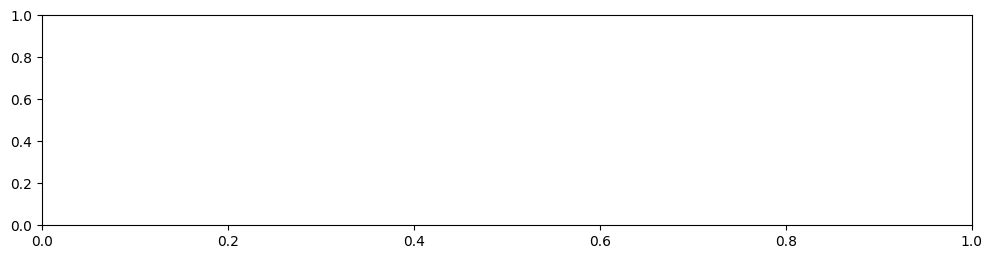

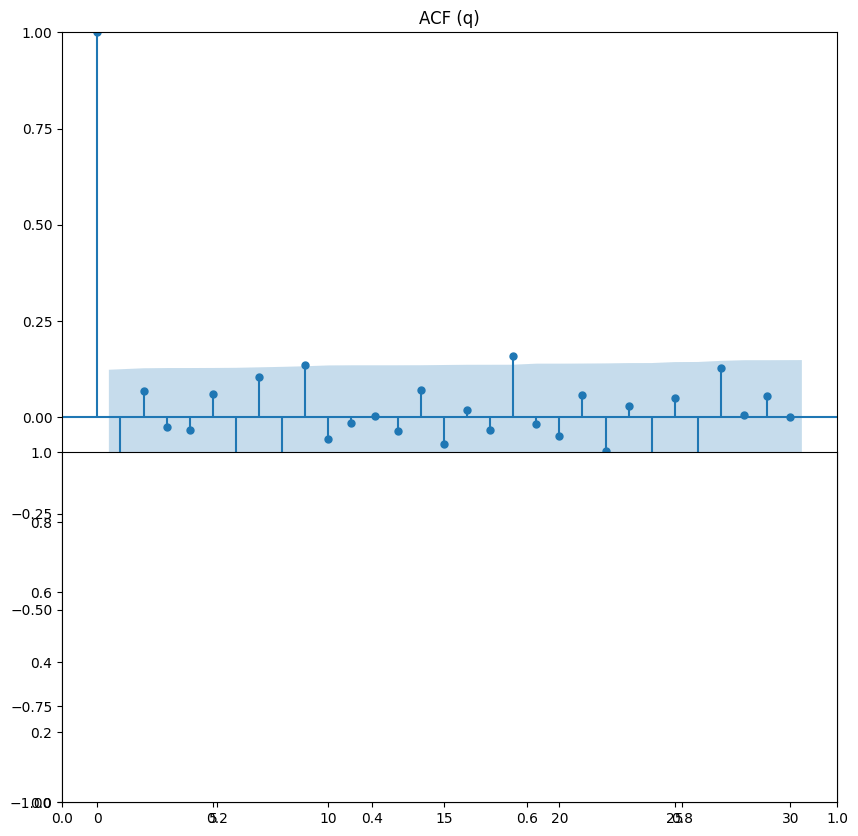

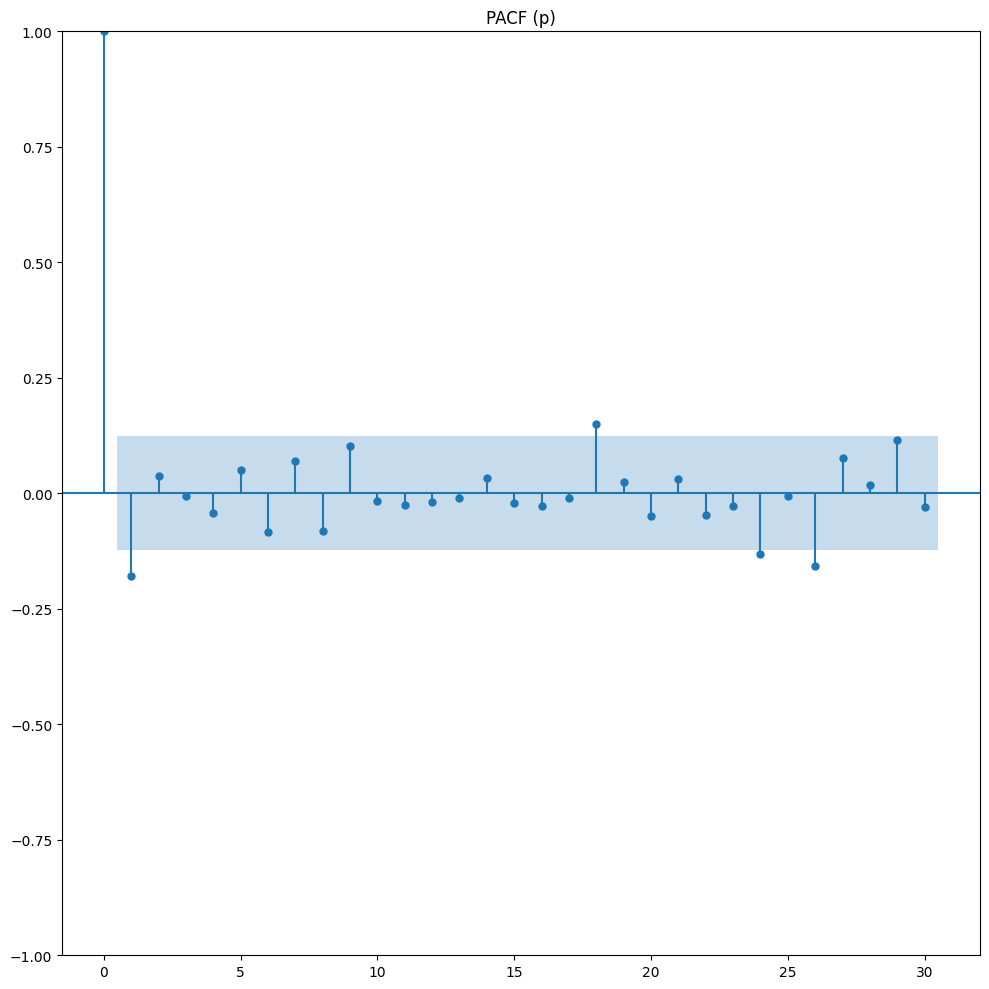

In [243]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Difference the 'adj_close' column to make it stationary
aapl_ar['adj_close_diff'] = aapl_ar['adj_close'].diff()
diff_series = aapl_ar['adj_close_diff'].dropna()

# Plot ACF and PACF
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plot_acf(diff_series, lags=30)
plt.title('ACF (q)')

plt.subplot(2, 1, 2)
plot_pacf(diff_series, lags=30)
plt.title('PACF (p)')

plt.tight_layout()
plt.show()


Actual vs Predicted (Days 1, 3, and 7 of December 2020):
      Date  Actual adj_close  Predicted adj_close
2020-12-01        120.590256           117.096241
2020-12-03        120.806435           117.410225
2020-12-09        119.666588           118.392607


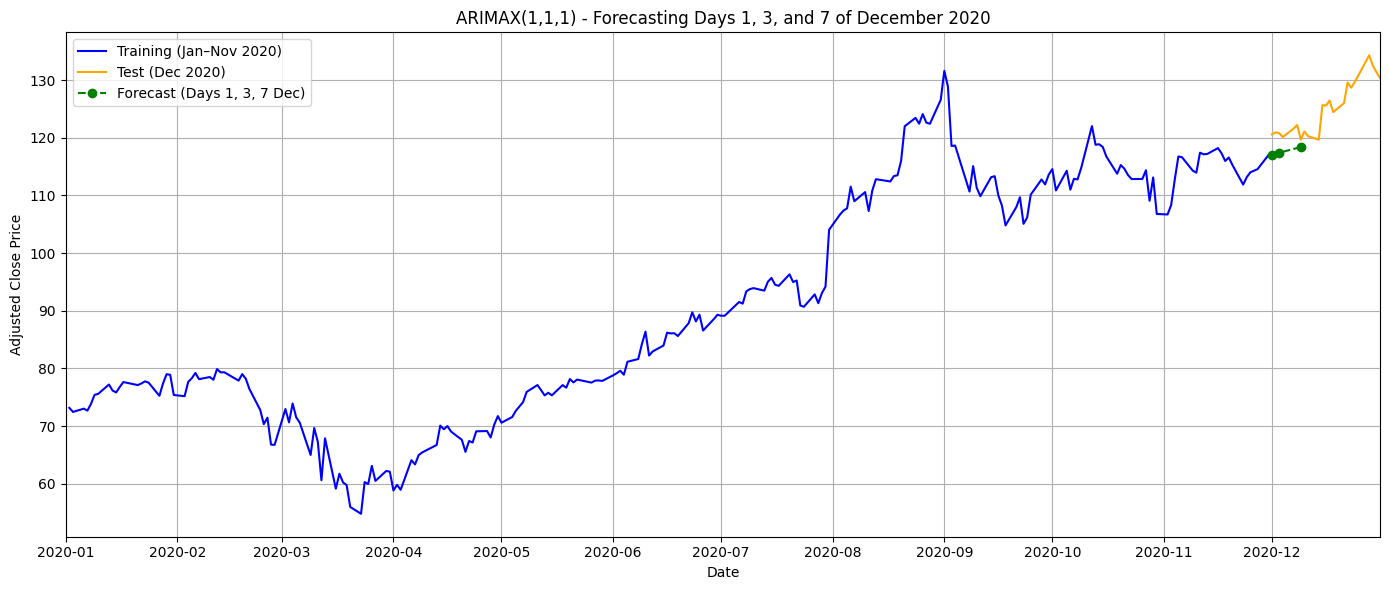

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Extract month and year
aapl_ar['month'] = aapl_ar['Date'].dt.month
aapl_ar['year'] = aapl_ar['Date'].dt.year

# Filter data for 2020 only
aapl_ar = aapl_ar[aapl_ar['year'] == 2020].copy()

# Train: Jan to Nov 2020
train_df = aapl_ar[aapl_ar['month'] < 12]

# Test: Dec 2020
test_df = aapl_ar[aapl_ar['month'] == 12]

# SARIMAX model
endog = train_df['adj_close']
exog = train_df[['compound']]
model = SARIMAX(endog, exog=exog, order=(1, 1, 1), seasonal_order=(1, 1, 1, 5))
results = model.fit(disp=False)

# Forecast first 7 days of Dec 2020
forecast_exog = test_df[['compound']].iloc[:7]
forecast = results.get_forecast(steps=7, exog=forecast_exog)
forecast_values = forecast.predicted_mean
forecast_dates = test_df['Date'].iloc[:7]
actual_values = test_df['adj_close'].iloc[:7]

# Select Days 1, 3, and 7 (indices 0, 2, 6)
selected_indices = [0, 2, 6]
dates_subset = forecast_dates.iloc[selected_indices]
forecast_subset = forecast_values.iloc[selected_indices]
actual_subset = actual_values.iloc[selected_indices]

# Compare actual vs predicted
comparison_df = pd.DataFrame({
    'Date': dates_subset.values,
    'Actual adj_close': actual_subset.values,
    'Predicted adj_close': forecast_subset.values
})

print("Actual vs Predicted (Days 1, 3, and 7 of December 2020):")
print(comparison_df.to_string(index=False))

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(train_df['Date'], train_df['adj_close'], label='Training (Jan–Nov 2020)', color='blue')
plt.plot(test_df['Date'], test_df['adj_close'], label='Test (Dec 2020)', color='orange')
plt.plot(dates_subset, forecast_subset, label='Forecast (Days 1, 3, 7 Dec)', color='green', marker='o', linestyle='--')

plt.title("ARIMAX(1,1,1) - Forecasting Days 1, 3, and 7 of December 2020")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"))
plt.show()


In [139]:
ba_ar = merged_df[merged_df['ticker'] == 'BA']

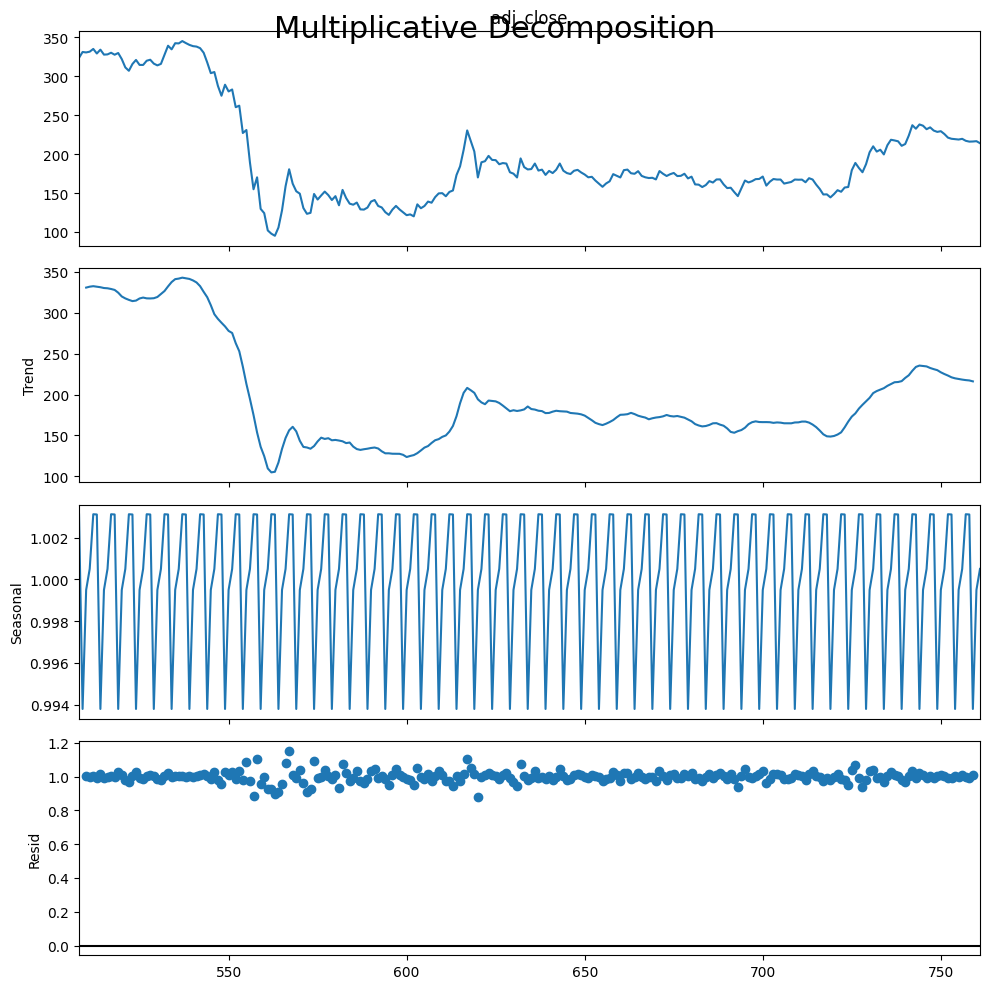

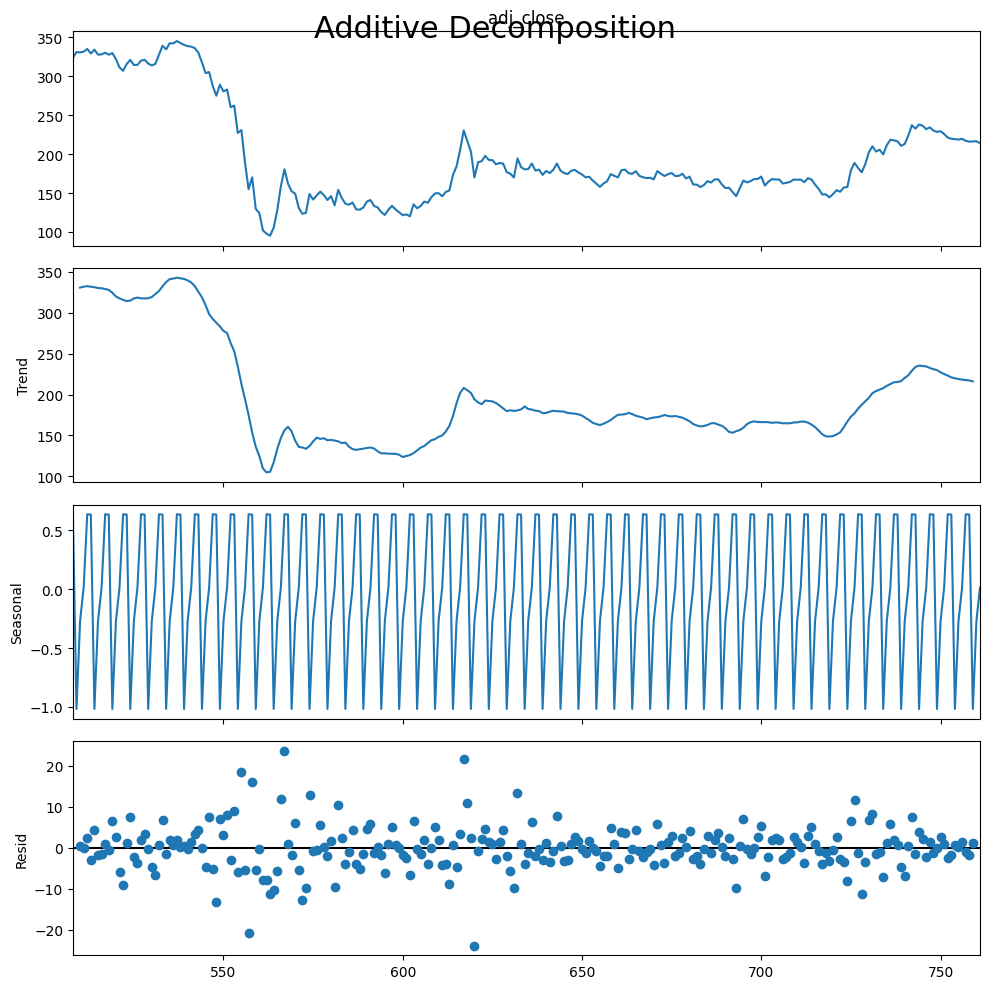

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition (5 = weekly pattern for daily stock data)
result_mul = seasonal_decompose(ba_ar['adj_close'], model='multiplicative', period=5)
result_add = seasonal_decompose(ba_ar['adj_close'], model='additive', period=5)

# Plot the results
plt.rcParams.update({'figure.figsize': (10, 10)})
result_mul.plot().suptitle('Multiplicative Decomposition', fontsize=22)
result_add.plot().suptitle('Additive Decomposition', fontsize=22)
plt.show()

In [143]:
from statsmodels.tsa.stattools import adfuller

# Ensure data is sorted by date
ba_ar = ba_ar.sort_values("Date")

# Select the series to test (e.g. adjusted closing price)
series = ba_ar['adj_close']

# Apply ADF test
result = adfuller(series)

# Print results
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Used lags:", result[2])
print("Observations:", result[3])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -2.292571167493479
p-value: 0.17437511321871102
Used lags: 2
Observations: 251
Critical Values:
   1%: -3.4566744514553016
   5%: -2.8731248767783426
   10%: -2.5729436702592023


In [147]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# Ensure data is sorted
ba_ar = ba_ar.sort_values("Date")

# Difference the series (1st order differencing)
ba_ar['adj_close_diff'] = ba_ar['adj_close'].diff()

# Drop the NaN introduced by differencing
series_diff = ba_ar['adj_close_diff'].dropna()

# Apply ADF test on differenced series
result = adfuller(series_diff)

# Print results
print("ADF Statistic (1st difference):", result[0])
print("p-value:", result[1])
print("Used lags:", result[2])
print("Observations:", result[3])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")


ADF Statistic (1st difference): -8.86248588318974
p-value: 1.470079215168662e-14
Used lags: 1
Observations: 251
Critical Values:
   1%: -3.4566744514553016
   5%: -2.8731248767783426
   10%: -2.5729436702592023


In [151]:
#after the forst differencing the dataset is stationary. therefore d =1

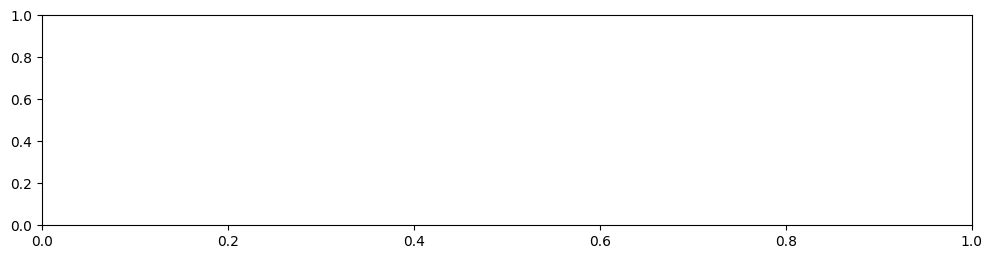

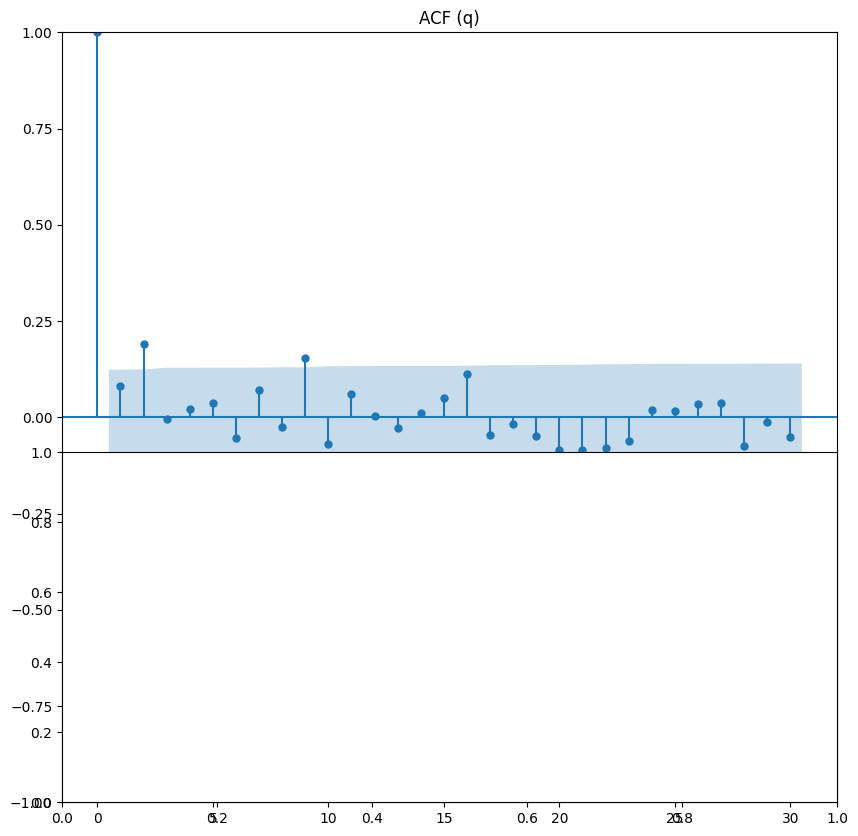

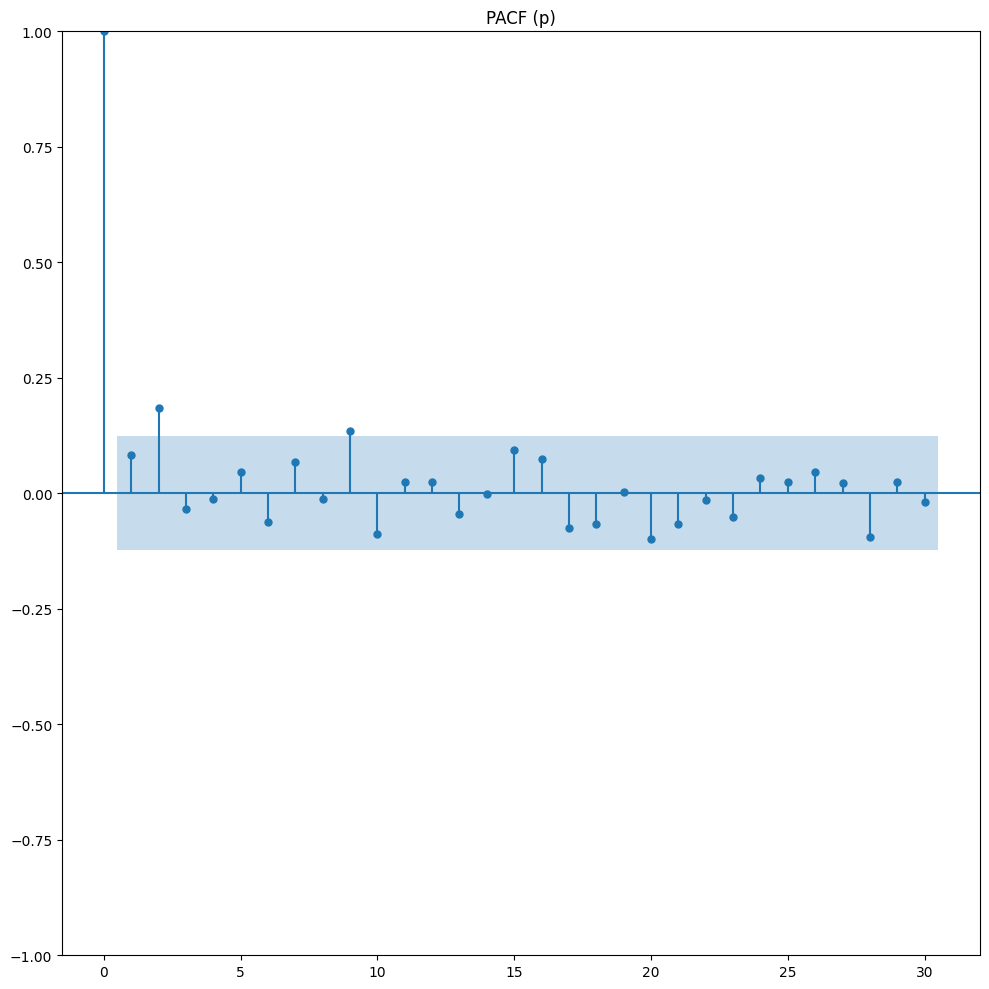

In [245]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Difference the 'adj_close' column to make it stationary
ba_ar['adj_close_diff'] = ba_ar['adj_close'].diff()
diff_series = ba_ar['adj_close_diff'].dropna()

# Plot ACF and PACF
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plot_acf(diff_series, lags=30)
plt.title('ACF (q)')

plt.subplot(2, 1, 2)
plot_pacf(diff_series, lags=30)
plt.title('PACF (p)')

plt.tight_layout()
plt.show()

In [159]:
#same as previous datsets. D is blank as already differenced. q and q are 1

In [163]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Extract month and year
ba_ar['month'] = ba_ar['Date'].dt.month
ba_ar['year'] = ba_ar['Date'].dt.year

# Filter data for 2020 only
ba_ar = ba_ar[ba_ar['year'] == 2020].copy()

# Train: Jan to Nov 2020
train_df = ba_ar[ba_ar['month'] < 12]

# Test: Dec 2020
test_df = ba_ar[ba_ar['month'] == 12]

# SARIMAX model
endog = train_df['adj_close']
exog = train_df[['compound']]
model = SARIMAX(endog, exog=exog, order=(1, 1, 1), seasonal_order=(1, 1, 1, 5))
results = model.fit(disp=False)

# Forecast first 7 days of Dec 2020
forecast_exog = test_df[['compound']].iloc[:7]
forecast = results.get_forecast(steps=7, exog=forecast_exog)
forecast_values = forecast.predicted_mean
forecast_dates = test_df['Date'].iloc[:7]
actual_values = test_df['adj_close'].iloc[:7]

# Select Days 1, 3, and 7 (indices 0, 2, 6)
selected_indices = [0, 2, 6]
dates_subset = forecast_dates.iloc[selected_indices]
forecast_subset = forecast_values.iloc[selected_indices]
actual_subset = actual_values.iloc[selected_indices]

# Compare actual vs predicted
comparison_df = pd.DataFrame({
    'Date': dates_subset.values,
    'Actual adj_close': actual_subset.values,
    'Predicted adj_close': forecast_subset.values
})

print("Actual vs Predicted (Days 1, 3, and 7 of December 2020):")
print(comparison_df.to_string(index=False))

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(train_df['Date'], train_df['adj_close'], label='Training (Jan–Nov 2020)', color='blue')
plt.plot(test_df['Date'], test_df['adj_close'], label='Test (Dec 2020)', color='orange')
plt.plot(dates_subset, forecast_subset, label='Forecast (Days 1, 3, 7 Dec)', color='green', marker='o', linestyle='--')

plt.title("ARIMAX(1,1,1) - Forecasting Days 1, 3, and 7 of December 2020")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"))
plt.show()


MissingDataError: exog contains inf or nans

In [165]:
# Check for NaN values in key columns
nan_check = train_df[['adj_close', 'compound']].isnull().sum()
print("NaN values in training data:")
print(nan_check)


NaN values in training data:
adj_close    0
compound     3
dtype: int64


In [185]:
#there are NAN values. I beleive this occured becasue when I merged the proce and sentiment files there was no corresponding sentiment score for the date
# and fill foreward didn't work as there was more than one blank compound score

In [175]:
merged_df['compound'] = merged_df.groupby('ticker')['compound'].transform(lambda x: x.ffill().bfill())


In [177]:
ba_ar = merged_df[merged_df['ticker'] == 'BA'].copy()
print(ba_ar['compound'].isnull().sum())  # Final safety check


0


Actual vs Predicted (Days 1, 3, and 7 of December 2020):
      Date  Actual adj_close  Predicted adj_close
2020-12-01        213.009995           211.145694
2020-12-03        237.199997           211.700054
2020-12-09        232.059998           210.501208


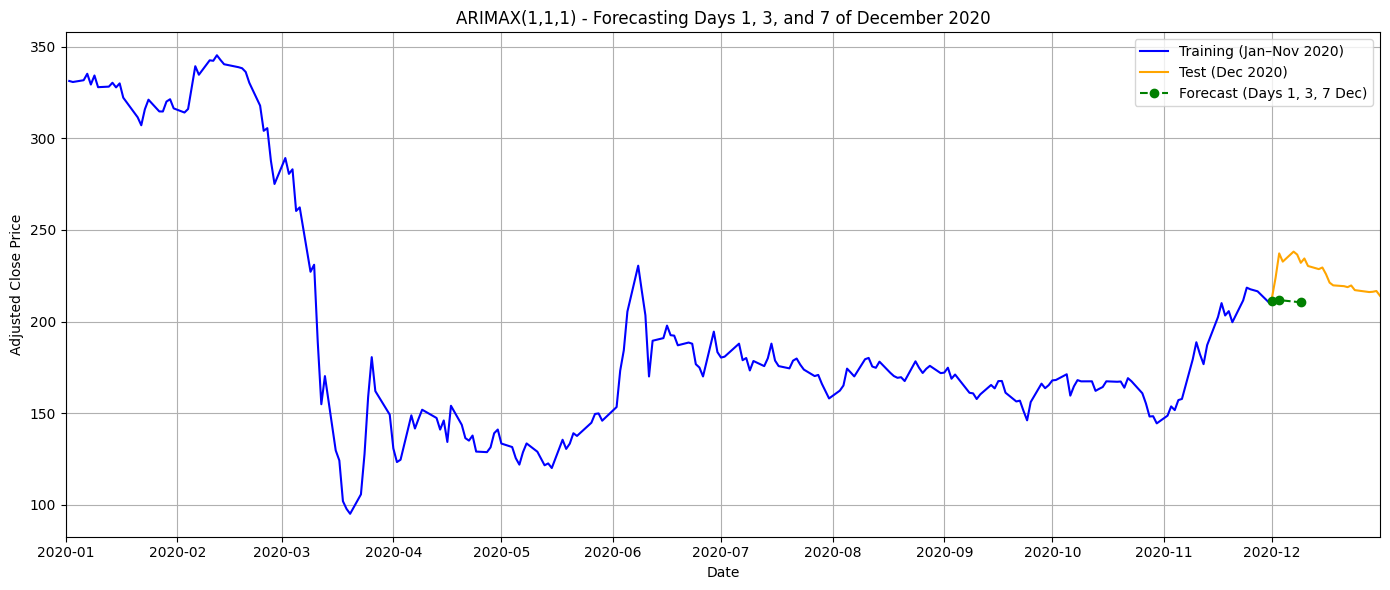

In [179]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Extract month and year
ba_ar['month'] = ba_ar['Date'].dt.month
ba_ar['year'] = ba_ar['Date'].dt.year

# Filter data for 2020 only
ba_ar = ba_ar[ba_ar['year'] == 2020].copy()

# Train: Jan to Nov 2020
train_df = ba_ar[ba_ar['month'] < 12]

# Test: Dec 2020
test_df = ba_ar[ba_ar['month'] == 12]

# SARIMAX model
endog = train_df['adj_close']
exog = train_df[['compound']]
model = SARIMAX(endog, exog=exog, order=(1, 1, 1), seasonal_order=(1, 1, 1, 5))
results = model.fit(disp=False)

# Forecast first 7 days of Dec 2020
forecast_exog = test_df[['compound']].iloc[:7]
forecast = results.get_forecast(steps=7, exog=forecast_exog)
forecast_values = forecast.predicted_mean
forecast_dates = test_df['Date'].iloc[:7]
actual_values = test_df['adj_close'].iloc[:7]

# Select Days 1, 3, and 7 (indices 0, 2, 6)
selected_indices = [0, 2, 6]
dates_subset = forecast_dates.iloc[selected_indices]
forecast_subset = forecast_values.iloc[selected_indices]
actual_subset = actual_values.iloc[selected_indices]

# Compare actual vs predicted
comparison_df = pd.DataFrame({
    'Date': dates_subset.values,
    'Actual adj_close': actual_subset.values,
    'Predicted adj_close': forecast_subset.values
})

print("Actual vs Predicted (Days 1, 3, and 7 of December 2020):")
print(comparison_df.to_string(index=False))

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(train_df['Date'], train_df['adj_close'], label='Training (Jan–Nov 2020)', color='blue')
plt.plot(test_df['Date'], test_df['adj_close'], label='Test (Dec 2020)', color='orange')
plt.plot(dates_subset, forecast_subset, label='Forecast (Days 1, 3, 7 Dec)', color='green', marker='o', linestyle='--')

plt.title("ARIMAX(1,1,1) - Forecasting Days 1, 3, and 7 of December 2020")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"))
plt.show()


In [181]:
dis_ar = merged_df[merged_df['ticker'] == 'DIS']

In [183]:
dis_ar = merged_df[merged_df['ticker'] == 'DIS'].copy()
print(dis_ar['compound'].isnull().sum())  # Final safety check


0


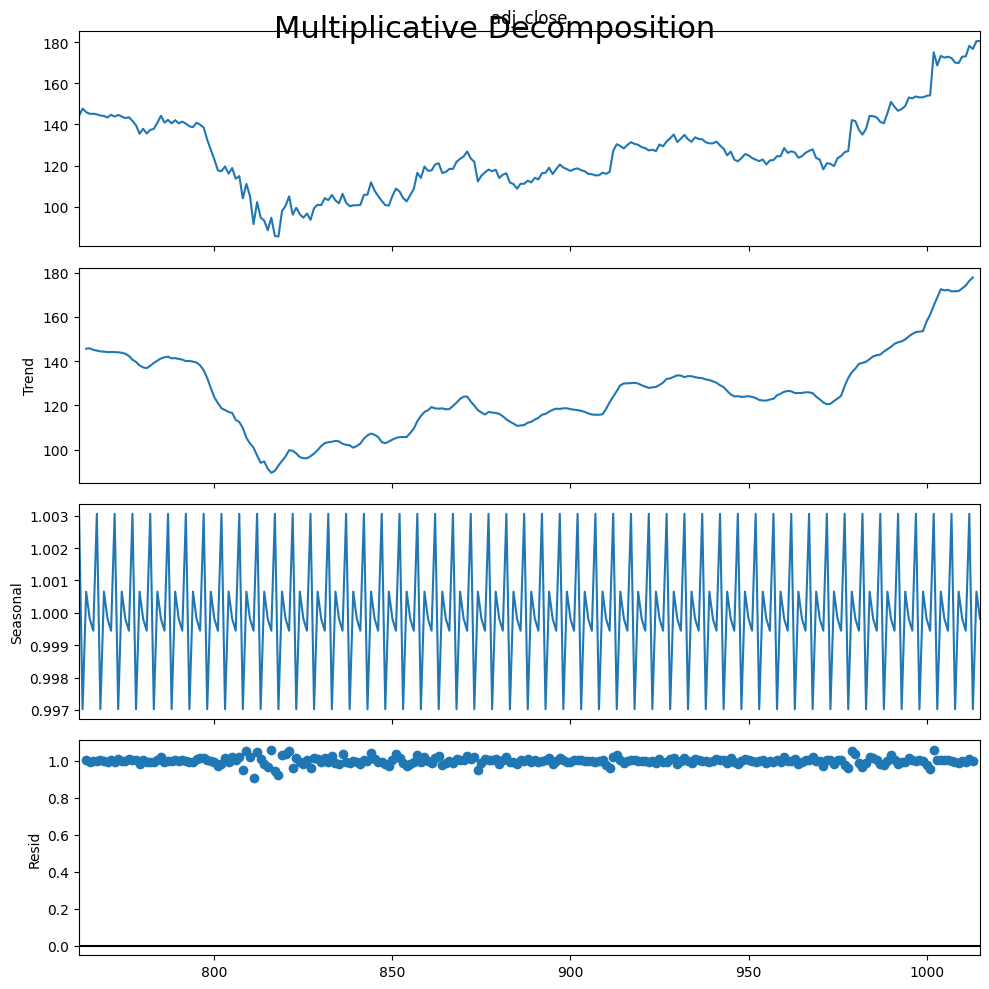

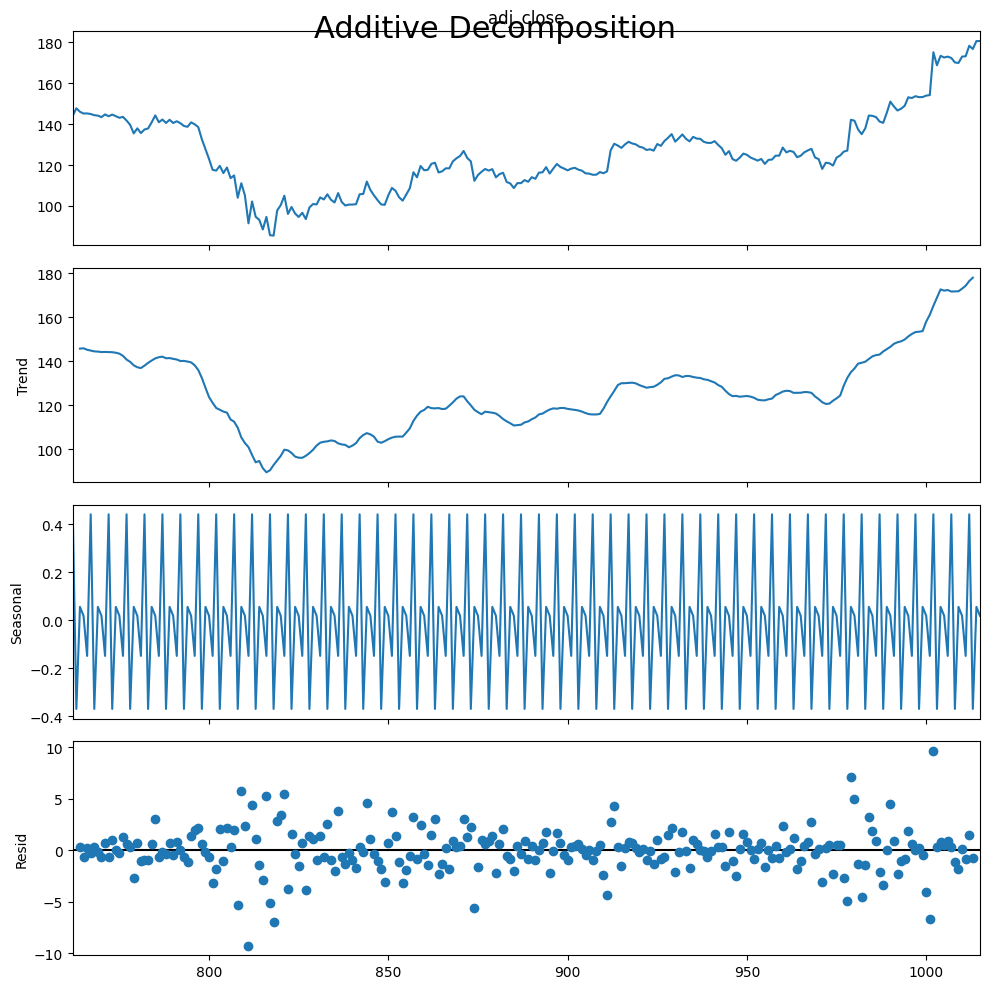

In [187]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition (5 = weekly pattern for daily stock data)
result_mul = seasonal_decompose(dis_ar['adj_close'], model='multiplicative', period=5)
result_add = seasonal_decompose(dis_ar['adj_close'], model='additive', period=5)

# Plot the results
plt.rcParams.update({'figure.figsize': (10, 10)})
result_mul.plot().suptitle('Multiplicative Decomposition', fontsize=22)
result_add.plot().suptitle('Additive Decomposition', fontsize=22)
plt.show()

In [189]:
# again there is a trend and seasonality. I Will confirm the non stationility below

In [191]:
from statsmodels.tsa.stattools import adfuller

# Ensure data is sorted by date
dis_ar = dis_ar.sort_values("Date")

# Select the series to test (e.g. adjusted closing price)
series = dis_ar['adj_close']

# Apply ADF test
result = adfuller(series)

# Print results
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Used lags:", result[2])
print("Observations:", result[3])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: 0.1659373050016638
p-value: 0.970285091525288
Used lags: 1
Observations: 252
Critical Values:
   1%: -3.4565688966099373
   5%: -2.8730786194395455
   10%: -2.5729189953388762


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF and PACF
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plot_acf(diff_series, lags=30)
plt.title('ACF (q)')

plt.subplot(2, 1, 2)
plot_pacf(diff_series, lags=30)
plt.title('PACF (p)')

plt.tight_layout()
plt.show()

In [193]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# Ensure data is sorted
dis_ar = dis_ar.sort_values("Date")

# Difference the series (1st order differencing)
dis_ar['adj_close_diff'] = dis_ar['adj_close'].diff()

# Drop the NaN introduced by differencing
series_diff = dis_ar['adj_close_diff'].dropna()

# Apply ADF test on differenced series
result = adfuller(series_diff)

# Print results
print("ADF Statistic (1st difference):", result[0])
print("p-value:", result[1])
print("Used lags:", result[2])
print("Observations:", result[3])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")


ADF Statistic (1st difference): -18.910427287287558
p-value: 0.0
Used lags: 0
Observations: 252
Critical Values:
   1%: -3.4565688966099373
   5%: -2.8730786194395455
   10%: -2.5729189953388762


In [197]:
#now stationary after 1 differencing

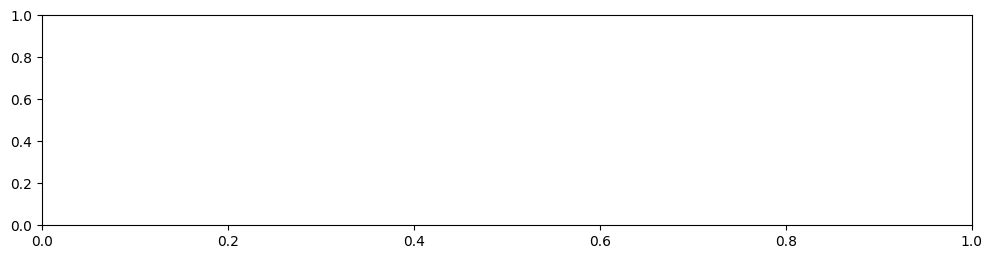

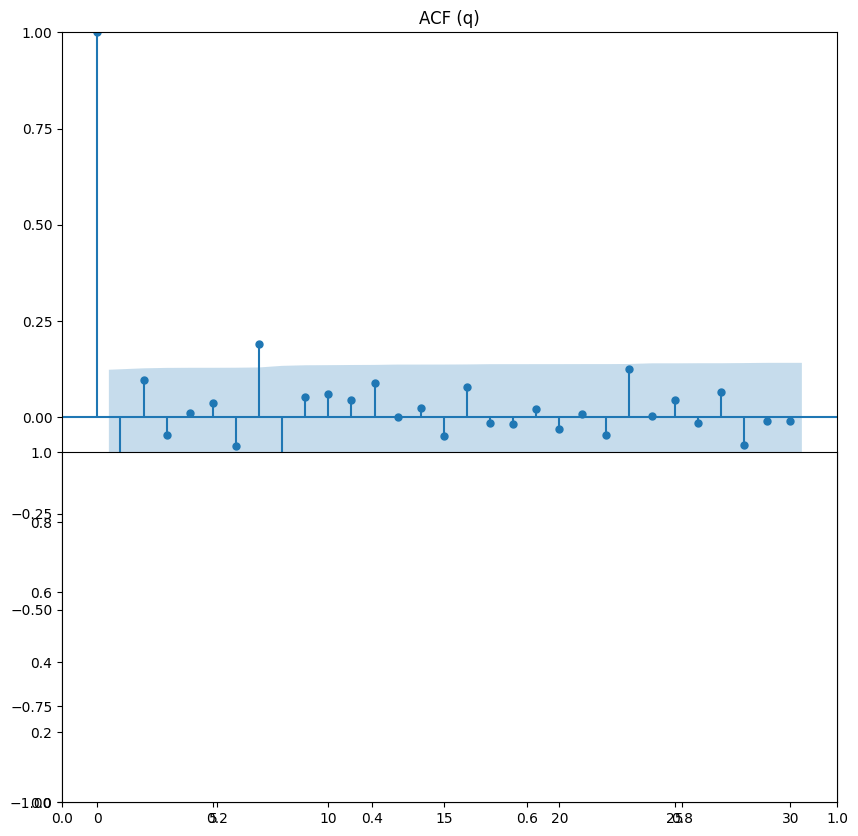

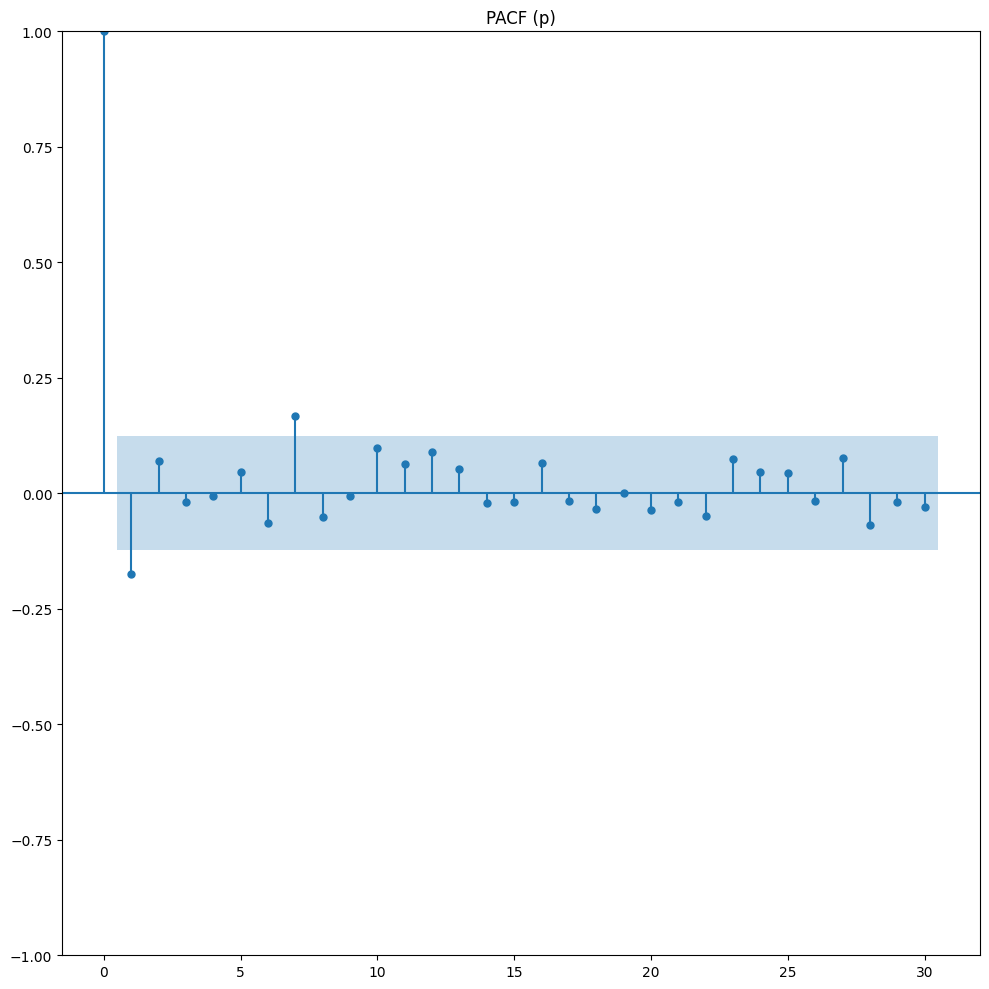

In [247]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Difference the 'adj_close' column to make it stationary
dis_ar['adj_close_diff'] = dis_ar['adj_close'].diff()
diff_series = dis_ar['adj_close_diff'].dropna()

# Plot ACF and PACF
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plot_acf(diff_series, lags=30)
plt.title('ACF (q)')

plt.subplot(2, 1, 2)
plot_pacf(diff_series, lags=30)
plt.title('PACF (p)')

plt.tight_layout()
plt.show()

In [215]:
# only the first lag is outside the bounds for both. therefore p and q are nil

Actual vs Predicted (Days 1, 3, and 7 of December 2020):
      Date  Actual adj_close  Predicted adj_close
2020-12-01        148.954544           148.199407
2020-12-03        152.742203           148.322456
2020-12-09        153.928329           149.631053


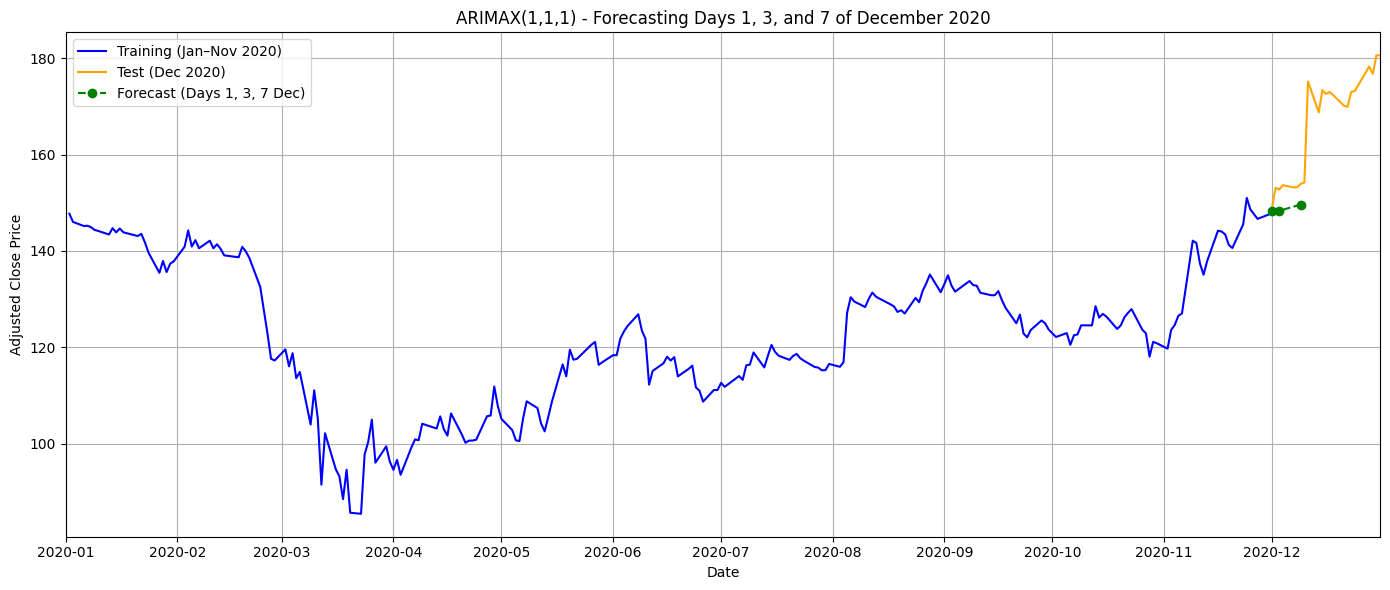

In [219]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Extract month and year
dis_ar['month'] = dis_ar['Date'].dt.month
dis_ar['year'] = dis_ar['Date'].dt.year

# Filter data for 2020 only
dis_ar = dis_ar[dis_ar['year'] == 2020].copy()

# Train: Jan to Nov 2020
train_df = dis_ar[dis_ar['month'] < 12]

# Test: Dec 2020
test_df = dis_ar[dis_ar['month'] == 12]

# SARIMAX model
endog = train_df['adj_close']
exog = train_df[['compound']]
model = SARIMAX(endog, exog=exog, order=(1, 1, 1), seasonal_order=(1, 1, 1, 5))
results = model.fit(disp=False)

# Forecast first 7 days of Dec 2020
forecast_exog = test_df[['compound']].iloc[:7]
forecast = results.get_forecast(steps=7, exog=forecast_exog)
forecast_values = forecast.predicted_mean
forecast_dates = test_df['Date'].iloc[:7]
actual_values = test_df['adj_close'].iloc[:7]

# Select Days 1, 3, and 7 (indices 0, 2, 6)
selected_indices = [0, 2, 6]
dates_subset = forecast_dates.iloc[selected_indices]
forecast_subset = forecast_values.iloc[selected_indices]
actual_subset = actual_values.iloc[selected_indices]

# Compare actual vs predicted
comparison_df = pd.DataFrame({
    'Date': dates_subset.values,
    'Actual adj_close': actual_subset.values,
    'Predicted adj_close': forecast_subset.values
})

print("Actual vs Predicted (Days 1, 3, and 7 of December 2020):")
print(comparison_df.to_string(index=False))

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(train_df['Date'], train_df['adj_close'], label='Training (Jan–Nov 2020)', color='blue')
plt.plot(test_df['Date'], test_df['adj_close'], label='Test (Dec 2020)', color='orange')
plt.plot(dates_subset, forecast_subset, label='Forecast (Days 1, 3, 7 Dec)', color='green', marker='o', linestyle='--')

plt.title("ARIMAX(1,1,1) - Forecasting Days 1, 3, and 7 of December 2020")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"))
plt.show()


In [221]:
amzn_ar = merged_df[merged_df['ticker'] == 'AMZN']

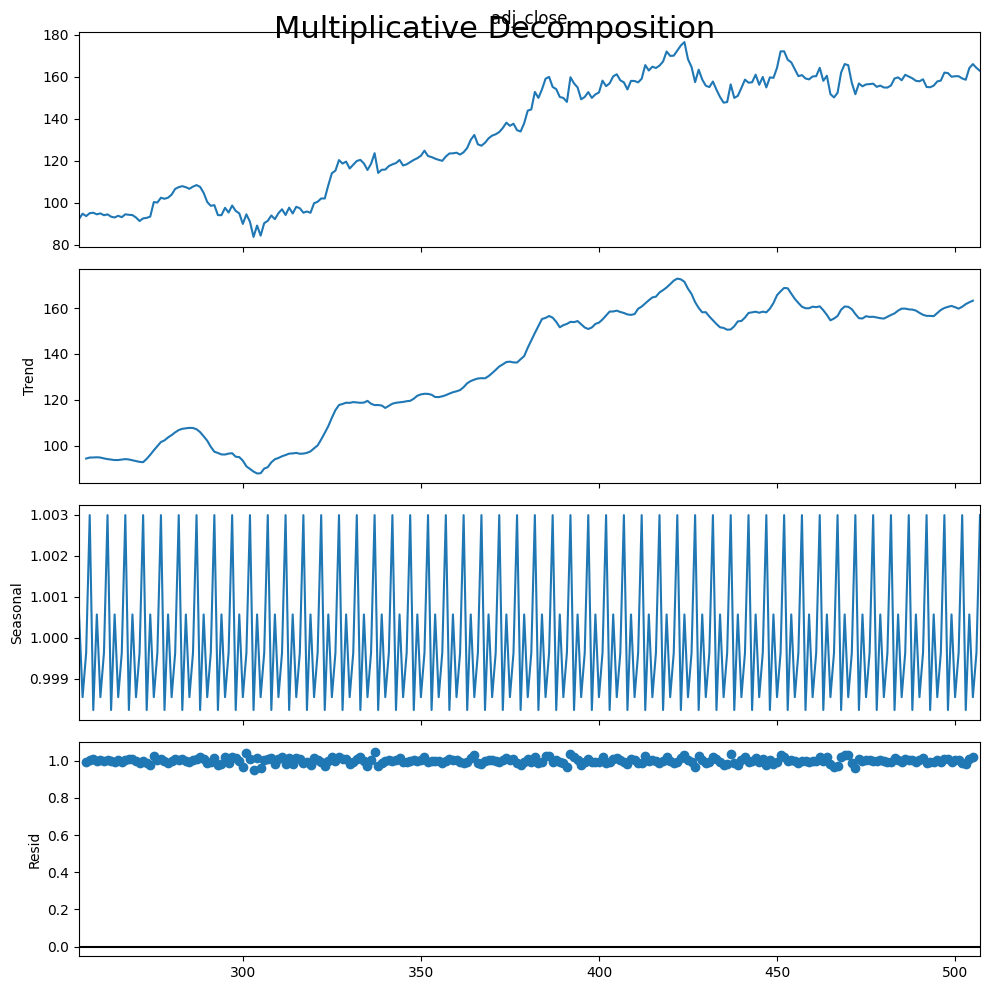

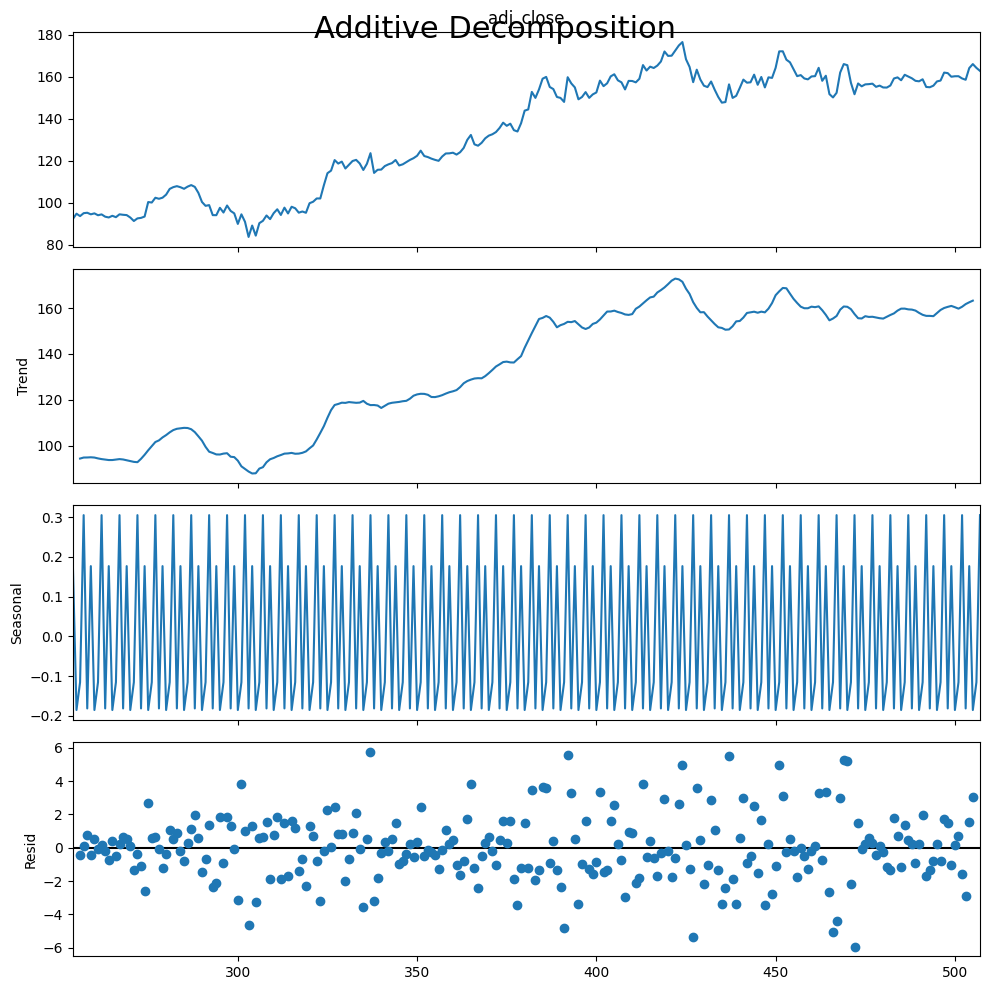

In [223]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition (5 = weekly pattern for daily stock data)
result_mul = seasonal_decompose(amzn_ar['adj_close'], model='multiplicative', period=5)
result_add = seasonal_decompose(amzn_ar['adj_close'], model='additive', period=5)

# Plot the results
plt.rcParams.update({'figure.figsize': (10, 10)})
result_mul.plot().suptitle('Multiplicative Decomposition', fontsize=22)
result_add.plot().suptitle('Additive Decomposition', fontsize=22)
plt.show()

In [225]:
#there is a a trend and seasonility. Will look into differening next

In [227]:
from statsmodels.tsa.stattools import adfuller

# Ensure data is sorted by date
amzn_ar = amzn_ar.sort_values("Date")

# Select the series to test (e.g. adjusted closing price)
series = amzn_ar['adj_close']

# Apply ADF test
result = adfuller(series)

# Print results
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Used lags:", result[2])
print("Observations:", result[3])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -1.0820828417838009
p-value: 0.7221639183796149
Used lags: 3
Observations: 250
Critical Values:
   1%: -3.456780859712
   5%: -2.8731715065600003
   10%: -2.572968544


In [231]:
# greatter than 0.05, fail to reject null hypothises and therefore dataset is non stationary

In [229]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# Ensure data is sorted
amzn_ar = amzn_ar.sort_values("Date")

# Difference the series (1st order differencing)
amzn_ar['adj_close_diff'] = amzn_ar['adj_close'].diff()

# Drop the NaN introduced by differencing
series_diff = amzn_ar['adj_close_diff'].dropna()

# Apply ADF test on differenced series
result = adfuller(series_diff)

# Print results
print("ADF Statistic (1st difference):", result[0])
print("p-value:", result[1])
print("Used lags:", result[2])
print("Observations:", result[3])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")


ADF Statistic (1st difference): -10.53437620500882
p-value: 8.979917740654117e-19
Used lags: 2
Observations: 250
Critical Values:
   1%: -3.456780859712
   5%: -2.8731715065600003
   10%: -2.572968544


In [233]:
# p-value is significantly below 0.05, so we reject the null hypothesis. The differenced series is stationary.

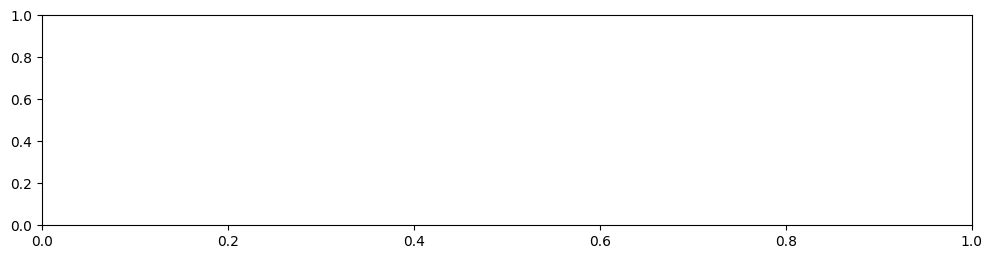

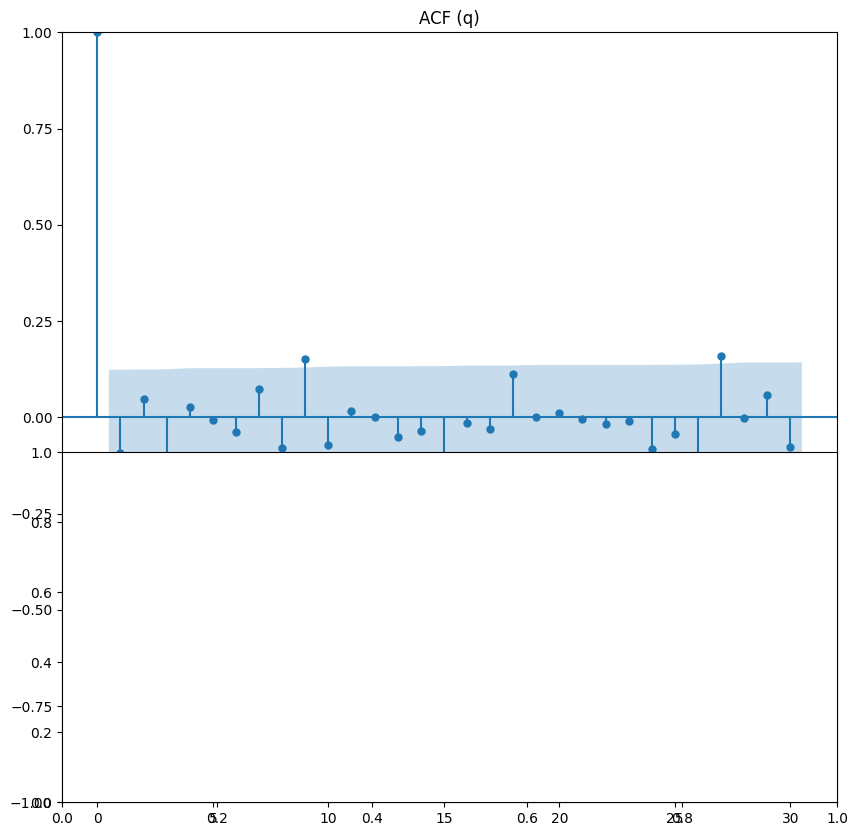

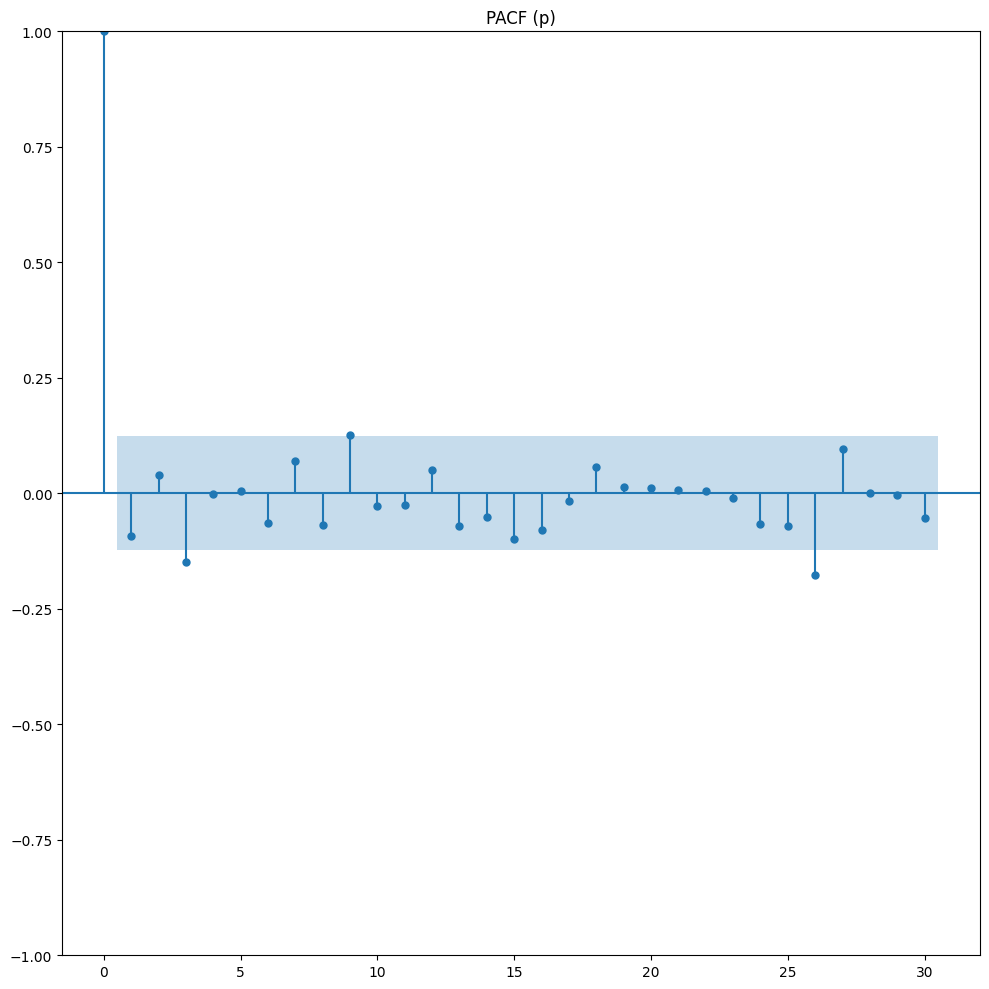

In [249]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Difference the 'adj_close' column to make it stationary
amzn_ar['adj_close_diff'] = amzn_ar['adj_close'].diff()
diff_series = amzn_ar['adj_close_diff'].dropna()

# Plot ACF and PACF
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plot_acf(diff_series, lags=30)
plt.title('ACF (q)')

plt.subplot(2, 1, 2)
plot_pacf(diff_series, lags=30)
plt.title('PACF (p)')

plt.tight_layout()
plt.show()

Actual vs Predicted (Days 1, 3, and 7 of December 2020):
      Date  Actual adj_close  Predicted adj_close
2020-12-01        161.003998           158.697257
2020-12-03        159.336502           159.417571
2020-12-09        155.210007           160.946615


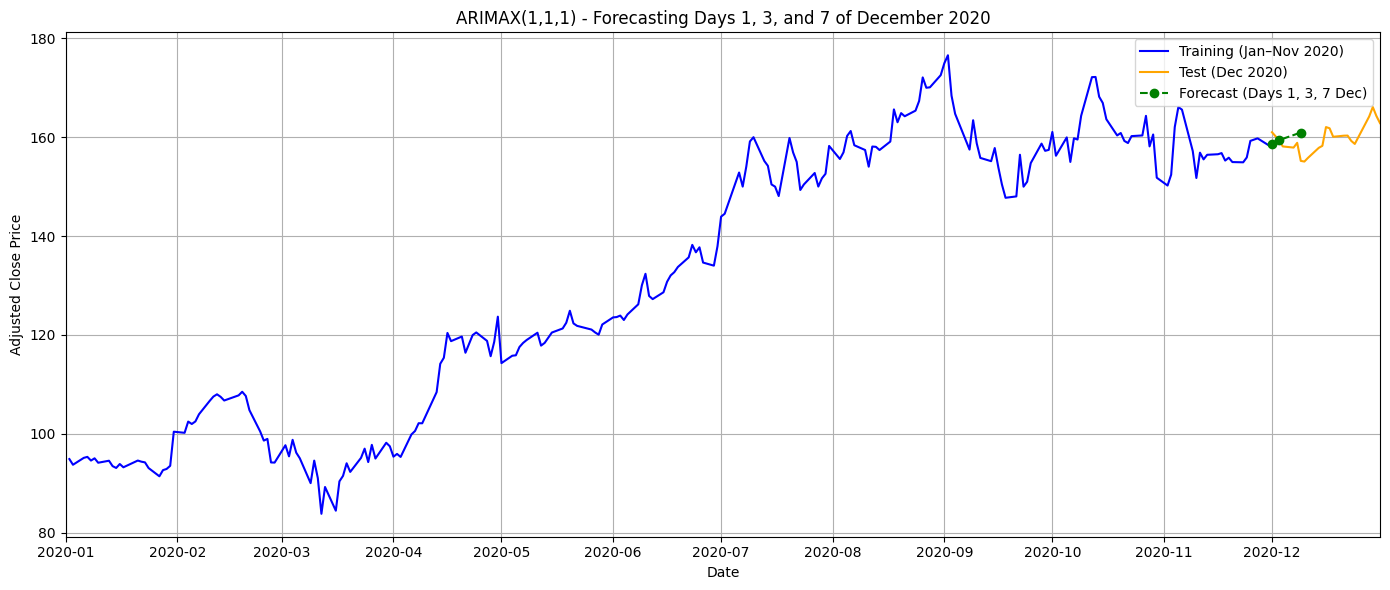

In [251]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Extract month and year
amzn_ar['month'] = amzn_ar['Date'].dt.month
amzn_ar['year'] = amzn_ar['Date'].dt.year

# Filter data for 2020 only
amzn_ar = amzn_ar[amzn_ar['year'] == 2020].copy()

# Train: Jan to Nov 2020
train_df = amzn_ar[amzn_ar['month'] < 12]

# Test: Dec 2020
test_df = amzn_ar[amzn_ar['month'] == 12]

# SARIMAX model
endog = train_df['adj_close']
exog = train_df[['compound']]
model = SARIMAX(endog, exog=exog, order=(1, 1, 1), seasonal_order=(1, 1, 1, 5))
results = model.fit(disp=False)

# Forecast first 7 days of Dec 2020
forecast_exog = test_df[['compound']].iloc[:7]
forecast = results.get_forecast(steps=7, exog=forecast_exog)
forecast_values = forecast.predicted_mean
forecast_dates = test_df['Date'].iloc[:7]
actual_values = test_df['adj_close'].iloc[:7]

# Select Days 1, 3, and 7 (indices 0, 2, 6)
selected_indices = [0, 2, 6]
dates_subset = forecast_dates.iloc[selected_indices]
forecast_subset = forecast_values.iloc[selected_indices]
actual_subset = actual_values.iloc[selected_indices]

# Compare actual vs predicted
comparison_df = pd.DataFrame({
    'Date': dates_subset.values,
    'Actual adj_close': actual_subset.values,
    'Predicted adj_close': forecast_subset.values
})

print("Actual vs Predicted (Days 1, 3, and 7 of December 2020):")
print(comparison_df.to_string(index=False))

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(train_df['Date'], train_df['adj_close'], label='Training (Jan–Nov 2020)', color='blue')
plt.plot(test_df['Date'], test_df['adj_close'], label='Test (Dec 2020)', color='orange')
plt.plot(dates_subset, forecast_subset, label='Forecast (Days 1, 3, 7 Dec)', color='green', marker='o', linestyle='--')

plt.title("ARIMAX(1,1,1) - Forecasting Days 1, 3, and 7 of December 2020")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"))
plt.show()
